# Supervised Machine Learning - To'liq Loyiha
## Data Preprocessing dan Model Deployment gacha
---
**Muallif:** Otakhanov loyihasi  
**Mavzu:** SUpervised ML - Classification and Regression  
**Kutubxonalar:** pandas, numpy, sklearn, matplotlib, seaborn, plotly, joblib, klib  

In [ ]:
            # --- "OS" oldindan papka yaratib olish ---

import os

# ========================================
# OS MODULE - Papka yaratish va boshqarish
# OS MODULE - Creating and managing folders
# ========================================

# os.makedirs() - papka yaratadi, exist_ok=True bo'lsa, papka mavjud bo'lsa xato bermaydi
# os.makedirs() - creates folder

# output_folder = 'data/preprecessed' ---> soddaroq usuli
folders = [
    'data/raw_datasets',        # Asl datasetlar / Orginal datasets
    'data/preprocessed',       # Tozalangan data / Cleaned data
    'data/engineered',          # Xususiyatlar yaratish / Feature engineering
    'data/predictions',         # Model bashoratlari / Model predictions
    'data_analysis',            # Tahlil natijalari / Analysis results
    'models',                   # Saqlangan modellar / Saved models
    'notebooks'                 # Notebook fayllar / Notebook files
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Papka yaratildi / Folder created: {folder}")

print("\n\tBarcha papkalar tayyor! / All folders ready!")  # \n - bu bitta qator tushirib beradi(New line) 
                                                           # \t - tab knobkasi bo'lib oldinga 4ta bo'sh joy(Tab space)

Papka yaratildi / Folder created: data/raw_datasets
Papka yaratildi / Folder created: data/preprocessed
Papka yaratildi / Folder created: data/engineered
Papka yaratildi / Folder created: data/predictions
Papka yaratildi / Folder created: data_analysis
Papka yaratildi / Folder created: models
Papka yaratildi / Folder created: notebooks

	Barcha papkalar tayyor! / All folders ready!


---
## Kutubxonalarni Import qilish
---

In [ ]:
# ================================================================================
# Barcha kutubxonalarni Import qilish / Importing all Libraries
# ================================================================================

    #   --- Asosiy kutubxonalar / Core libraries ---
import pandas as pd         # Ma'lumotlarni jadvallarda boshqarish uchun
                            # For data manipulation in tables
import numpy as np          # Matematik hisob-kitoblar uchun
                            # For mathematical computations

    #   --- Vizualizatsiya / Visualization ---
import matplotlib.pyplot as plt     # Asosiy grafik kutubxona
                                    # Core plotting library
import seaborn as sns               # Chiroyli statistik grafiklar
                                    # Beatiful statistical plots
import plotly.express as px         # Interaktiv grafiklar
                                    # Interactive charts

    #   --- Ma'lumotlarni tozalash / Data cleaning ---
import klib         # Tez va qulay tozalash
                    # Fast and convenient data cleaning
# pip install klib (agar o'rnatilmagan bo'lsa / if not installed)

        #   --- raw(xom) datasetni Machine Learning model uchun tayyorlash jarayoni / Preprocessing ---

    # --- Encoder ---
from sklearn.preprocessing import (
    LabelEncoder,           # katagoriyalarni raqamlarga aylantiradi
                            # Converts categories to numbers
    OneHotEncoder,          # Kategoriyalarni sun'iy ustun yaratib 0/1dan tashkil topgan qatorlarga aylantiradi
                            # Converts categories to 0/1 columns
    OrdinalEncoder,         # Tartibli kategoriyalarni kodlaydi
                            # Encodes ordered categories
    TargetEncoder,          # Kategoriyalarni target o'rtacha qiymati bilan almashtiradi
                            # Replaces categories using target mean
    
    # FrequencyEncoder      # encoder = FrequencyEncoder()
                            # df['data'] = encoder.fit_transform(df['data'])

    #from category_encoders import BinaryEncoder
    #BinaryEncoder,         # Kategoriyalarni binary ko'rinishiga o'tkazadi
                            # Converts categories into binary representation
)

    # --- Scaling ---
from sklearn.preprocessing import (
    StandardScaler,         # mean=0, std=1 ga keltiradi
                            # Scales to mean=0, std=1
    MinMaxScaler,           # 0-1 oralig'iga keltiradi
                            # Scales to 0-1 range
    RobustScaler,           # Outlier'larga chidamli scaling   # Outlier? — datasetdagi boshqa qiymatlardan juda uzoq yoki noodatiy qiymat.
                            # Robust to outliers scaling

    # bulardan tashqari
    MaxAbsScaler,           # -1 dan 1 gacha keltiradi
                            # Scales to -1 to 1 range
    Normalizer              # Har bir qatorni normalize qiladi
                            # Normalizes each row
)

# New for me
from sklearn.impute import SimpleImputer # ---> Yo'q qiymatlarni to'ldiradi / Fills missing values

from sklearn.model_selection import (
    train_test_split,           # Datasetni train va test qismlarga ajratadi
                                # Splits dataset info training and testing sets
    KFold,                      # Datasetni K ta qismga bo'lib cross validation qiladi
                                # Splits dataset info K folds for cross validation
    cross_val_score             # Cross validation orqali model baholash scorelarini hisoblaydi
                                # Evaluates model scores using scores using cross validation
)

    # --- Modellar / MOdels ---
# Classification
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Regression
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

        # --- Model baholash / Model evaluation ---
from sklearn.metrics import (
    confusion_matrix,           # To'g'ri/noto'g'ri predictionlarni jadvalda ko'rsatadi
                                # Shows correct/incorrect predictions in a table
    classification_report,      # Classification metrikalarini chiqaradi
                                # Displays classification metrics
    accuracy_score,             # To'g'ri prediction foizini hisoblaydi
                                # Calculates predictions accuracy
    precision_score,            # Positive prediction aniqligini hisoblaydi
                                # Measures positive prediction accuracy
    recall_score,               # Positive qiymatlarni topish darajasini hisoblaydi
                                # Measures ability to find positives
    f1_score,                   # Precision va recall o'rtachasini hisoblaydi
                                # Calculates balance of precision and recall
    log_loss,                   # Probability asosidagi xatoni hisoblaydi
                                # Measures probability-based error
    r2_score,                   # Regression model sifatini baholaydi
                                # Evaluates regression model performance
    mean_absolute_error,        # O'rtacha absolut xatoni hisoblaydi
                                # Calculates average absolute error
    mean_squared_error,         # O'rtacha kvadrat xatoni hisoblaydi
                                # Calculates average squared error
    root_mean_squared_error     # Kvadrat ildizli xatoni hisoblaydi
                                # Calculates root mean squared error
)

    # --- Model saqlash / Model saving ---
import joblib                   # Modelni faylga saqlash / Save model to file
# from joblib import joblib
from tabulate import tabulate

# New for me
    # --- Ogohlantirish xabarlarini o'chirish / Suppress warnings ---
import warnings
warnings.filterwarnings('ignore')

# Klib (pip install klib - agar o'rnatilmagan bo'lsa)
try:
    import klib
    KLIB_AVAILABLE = True
    print("Klib yuklandi/Klib loaded")
except ImportError:
    KLIB_AVAILABLE = False
    print("Klib o'rnatilmagan. pip install klib buyrug'ini ishlatib o'rnating")

print("Barcha kutubxonalar muvaffaqiyatli yuklandi! / All libraries loaded succesfully!")

Klib yuklandi/Klib loaded
Barcha kutubxonalar muvaffaqiyatli yuklandi! / All libraries loaded succesfully!


---
## Dataset yuklash va dastlabki ko'rish

# AI Student Impact - Supervised Machine Learning Loyihasi---
**Dataset:** `ai_student_impact.csv` - 50,000ta talaba, 16ta ustun  
**Classification Target:** `Burnout_Risk_Level` (High / Medium / Low)  
**Regression Target:** `Post_Semester_GPA` (raqamli qiymat)

| Ustun | Turi | Tavsif |
|-------|------|--------|
| Student_ID | int | Talaba ID raqami |
| Major_Category | kategorik | Yo'nalish (STEM, Business, Arts...) |
| Year_of_Study | kategorik | O'quv yili (Freshman...Graduate) |
| Pre_Semester_GPA | float | Oldingi semestr GPA |
| Weekly_GenAI_Hours | float | Haftada AI ishlatish soati |
| Primary_Use_Case | kategorik | AI dan asosiy foydalanish maqsadi |
| Prompt_Engineering_Skill | kategorik | Prompt ko'nikmasi darajasi |
| Tool_Diversity | int | Foydalanadigan AI vositalar soni |
| Paid_Subscription | bool | Pullik obuna |
| Traditional_Study_Hours | float | An'anaviy o'qish soati |
| Perceived_AI_Dependency | int | AI ga bog'liqlik darajasi (1-10) |
| Institutional_Policy | kategorik | Muassasa siyosati |
| Anxiety_Level_During_Exams | int | Imtihon davrida tashvish darajasi |
| Post_Semester_GPA | float | **REGRESSION TARGET** | 
| Skill_Retention_Score | float | Ko'nikma saqlash balli |
| Burnout_Risk_Level | kategorik | **CLASSIFICATION TARGET** |

In [ ]:
import os
import pandas as pd

# Fayl joylashuvini oldindan ham qilsak bo'larkan
# RAW_PATH = 'ai_student_impact.csv'
# df = pd.read_csv(RAW_PATH)

# ============================================
# Csv Dataset yuklash / Loading Csv dataset
# ============================================

# Csv faylni yuklaymiz / Load Csv file
import pandas as pd
df = pd.read_csv("ai_student_impact.csv")

    #   Preprocessed dataset saqlanadigan papka
    #   Folder where preprocessed dataset will be saved
# Output papka yaratish / Create output folder
output_folder = 'data/raw_datasets'

    #   Papkani yaratadi. Agar mavjud bo'lsa xato bermaydi
    #   Creates folder. exist_ok=True prevents error if folder already exists
os.makedirs(output_folder, exist_ok=True)

# Saqlash joyi / Save path
out_path = os.path.join(output_folder,'ai_student_impact.csv')
# 2-usuli ---> out_path = os.path.join('data', 'raw_datasets','ai_student_impact.csv')

# Datasetni saqlash / Save dataset
df.to_csv(out_path,index=False)

print("Raw Dataset saqlandi / Raw Dataset saved!")

print(f"\nDataset o'lchami / Shape: {df.shape}")
print(f"   {df.shape[0]:,} qator / rows, {df.shape[1]} ustun / columns")

print("\nBirinchi 5 qator / First 5 rows:")
print(df.head())

print("\nUstun turlari / Column types:")
print(df.dtypes)

print("\nStatistik ko'rsatkichlar / Statistical summary:")
display(df.describe())

Raw Dataset saqlandi / Raw Dataset saved!

Dataset o'lchami / Shape: (50000, 16)
   50,000 qator / rows, 16 ustun / columns

Birinchi 5 qator / First 5 rows:
   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0               23.31       Copywriting/Drafting                 Beginner   
1                1.12                   Ideation                 Advanced   
2               21.26        Summarizing_Reading                 Beginner   
3                1.82       Copywriting/Drafting             Intermediate   
4                9.29  Debugging/Troubleshooting                 Advance

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [ ]:
            # --- BU 'OS' ni to'liqroq versiyasi ---

import os

# ========================================
# Output Folder yaratish / Create Output Folder
# ========================================

    #   Preprocessed dataset saqlanadigan papka
    #   Folder where preprocessed dataset will be saved

output_folder = 'data/raw_datasets'

    #   Papkani yaratadi. Agar mavjud bo'lsa xato bermaydi
    #   Creates folder. exist_ok=True prevents error if folder already exists

os.makedirs(output_folder,exist_ok=True)

# ========================================
# File Path yaratish / Create File Path
# ========================================

    #   Papka va fayl nomini birlashtiradi
    #   Joins folder path and filename

output_path = os.path.join(
    output_folder,
    'ai_student_impact.csv'
)

# ========================================
# Datasetni saqlash / Save Dataset
# ========================================

    #   index=False
    #   Index ustunini saqlamaydi
    #   Prevents saving dataframe index column

df.to_csv(output_path, index=False)

# ========================================
# Tekshirish / Check
# ========================================

    #   Fayl saqlanganini chiqaradi
    #   Prints saved file location

print(f"\n Preprocessed dataset saved to: {output_path}")

# ========================================
# Papka ichidagi fayllar / Files inside Folder
# ========================================

print(f"\n Files inside folder:")
print(os.listdir(output_folder))

# ========================================
# Fayl mavjudligini tekshirish /File Exists check
# ========================================

print(f"\n File exists?: {os.path.exists(output_path)}")


 Preprocessed dataset saved to: data/raw_datasets\ai_student_impact.csv

 Files inside folder:
['ai_student_impact.csv']

 File exists?: True


---
## EDA - Klib va Korrelyatsiya Tahlili
### Klib qayerda ishlatiladi?
> **Klib preprocessing dan `oldin` ishlatiladi - dataset bilan tanishish bosqichida (EDA).  
> **Klib is used `before` preprocessing - during the dataset exploration stage (EDA)


In [ ]:
# EDA (Exploratory Data Analysis) - datasetni o‘rganish va tushunish jarayoni.
# KLib - Python kutubxonasi bo‘lib, avtomatik EDA qiladi.
# Korrelyatsiya (Correlation Analysis) - Bu featurelar bir-biriga qanchalik bog‘langanini aniqlaydi.

In [ ]:
# ========================================
# Klib - Tezkor EDA
#   klib.describe() - har bir ustun uchun to'liq statistika
#   klib.missingval_plot() - yo'q qiymatlar xaritasi
#   klib.dist_plot() - taqsimot grafiklari
#   klib.corr_plot() - korrelyatsiya grafigi
#   
#   Quick exploratory data analysis with one-liners
# ========================================

# ============================================================
# KLIB KUTUBXONASI
# ============================================================
# UZ: Klib - pandas va matplotlib ustiga qurilgan kutubxona bo'lib,
#     bir qator kod bilan datasetni tez tahlil qilish imkonini beradi.
#     QAYERda ishlatiladi: EDA (Exploratory Data Analysis) bosqichida,
#     ya'ni dataset bilan tanishish paytida, preprocessing dan OLDIN.
#
# EN: Klib is a library built on pandas and matplotlib that allows
#     quick dataset analysis with a single line of code.
#     WHERE to use: During EDA stage, BEFORE preprocessing, to understand data.

print("📊 Pandas describe (klib o'rniga / alternative):")
display(df.describe(include='all'))

📊 Pandas describe (klib o'rniga / alternative):


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
count,50000.000000,50000,50000,50000.000000,50000.000000,50000,50000,50000.00000,50000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000
unique,NaN,5,5,NaN,NaN,5,3,NaN,2,NaN,NaN,3,NaN,NaN,NaN,3
top,NaN,STEM,Junior,NaN,NaN,Debugging/Troubleshooting,Beginner,NaN,False,NaN,NaN,Allowed_With_Citation,NaN,NaN,NaN,Medium
freq,NaN,15059,11045,NaN,NaN,12295,18495,NaN,28846,NaN,NaN,25224,NaN,NaN,NaN,21144
mean,125000.500000,NaN,NaN,3.146102,8.427752,NaN,NaN,2.80026,NaN,11.209271,3.505360,NaN,4.270760,3.349299,75.798125,NaN
std,14433.901067,NaN,NaN,0.478854,8.269490,NaN,NaN,1.18802,NaN,5.156426,1.820812,NaN,2.144066,0.495673,13.281626,NaN
min,100001.000000,NaN,NaN,1.183000,0.000000,NaN,NaN,1.00000,NaN,1.000000,1.000000,NaN,1.000000,1.000000,10.780000,NaN
25%,112500.750000,NaN,NaN,2.834000,2.390000,NaN,NaN,2.00000,NaN,7.560000,2.000000,NaN,3.000000,3.023750,66.820000,NaN
50%,125000.500000,NaN,NaN,3.210000,5.800000,NaN,NaN,3.00000,NaN,11.180000,3.000000,NaN,4.000000,3.421000,76.000000,NaN
75%,137500.250000,NaN,NaN,3.521000,11.720000,NaN,NaN,4.00000,NaN,14.710000,5.000000,NaN,6.000000,3.749000,85.190000,NaN


In [ ]:
# ============================================================
# KLIB — Missing Values Grafigi
# UZ: Qaysi ustunlarda yo'q qiymatlar borligini vizual ko'rsatadi
# EN: Visually shows which columns have missing values
# ============================================================
if KLIB_AVAILABLE:
    klib.missingval_plot(df)
else:
    missing = df.isnull().sum()
    print("Missing values: " + missing)

No missing values found in the dataset.


Large dataset detected, using 10000 random samples for the plots. Summary statistics are still based on the entire dataset.


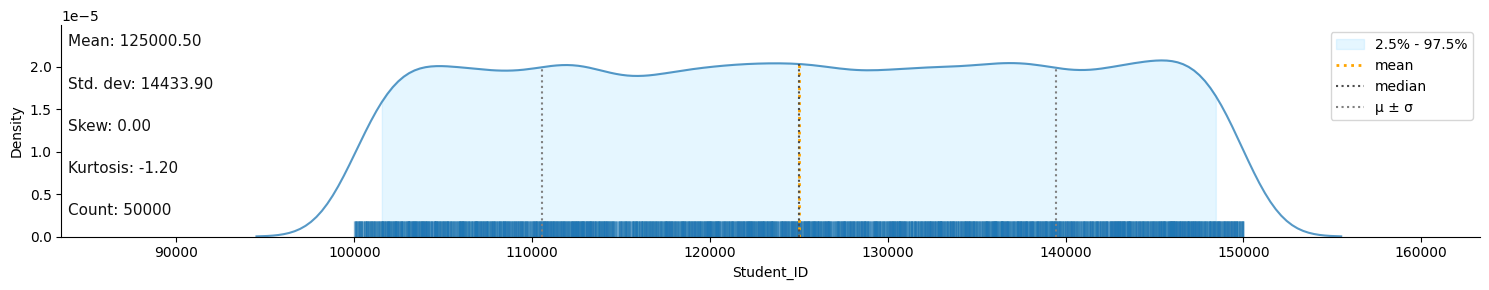

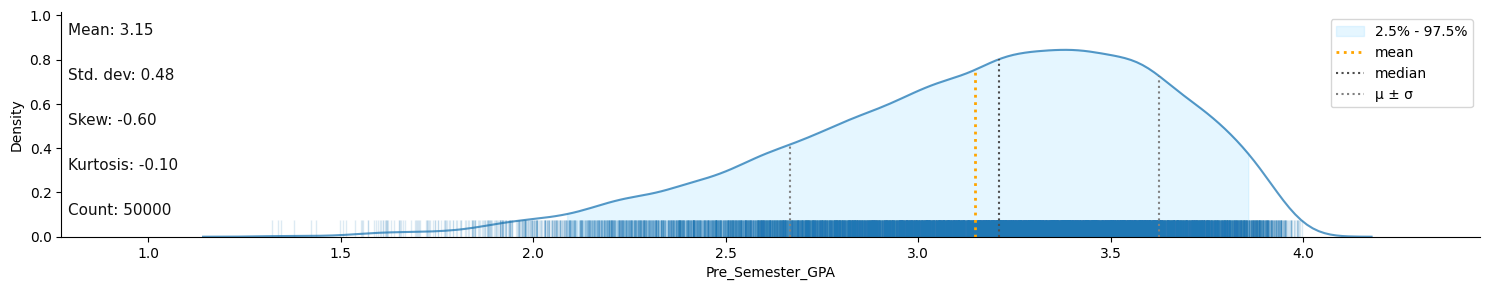

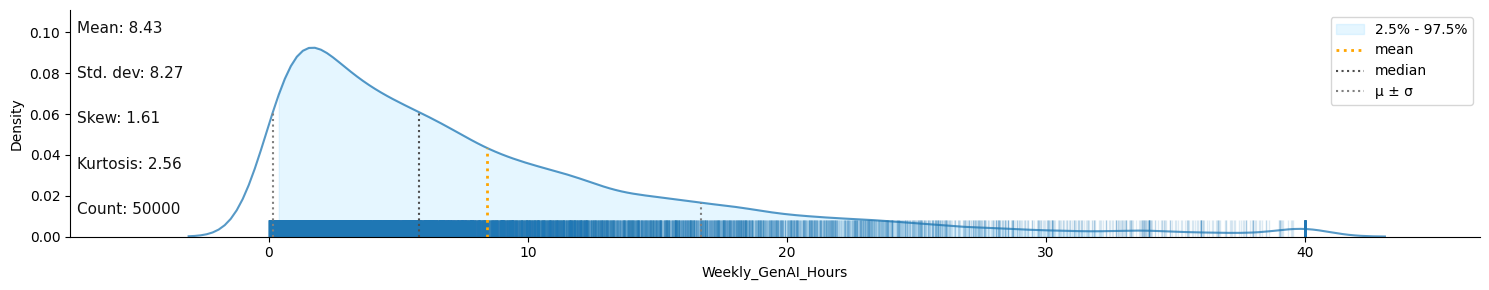

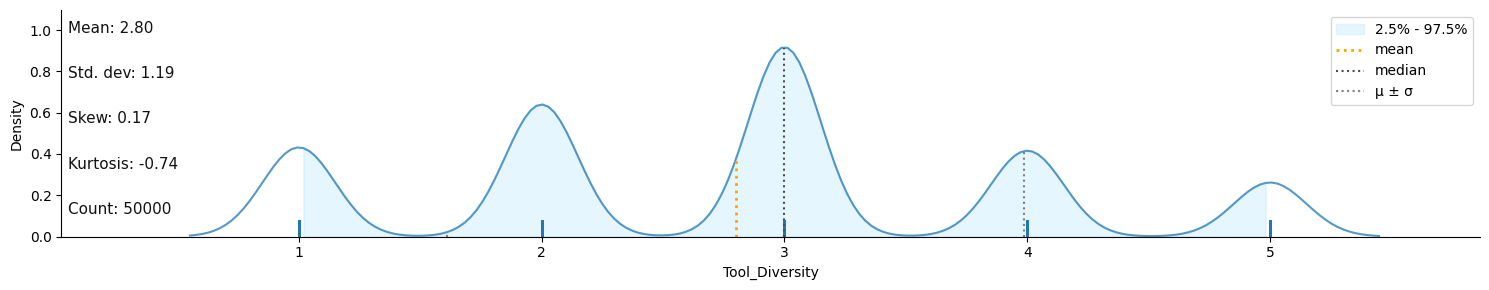

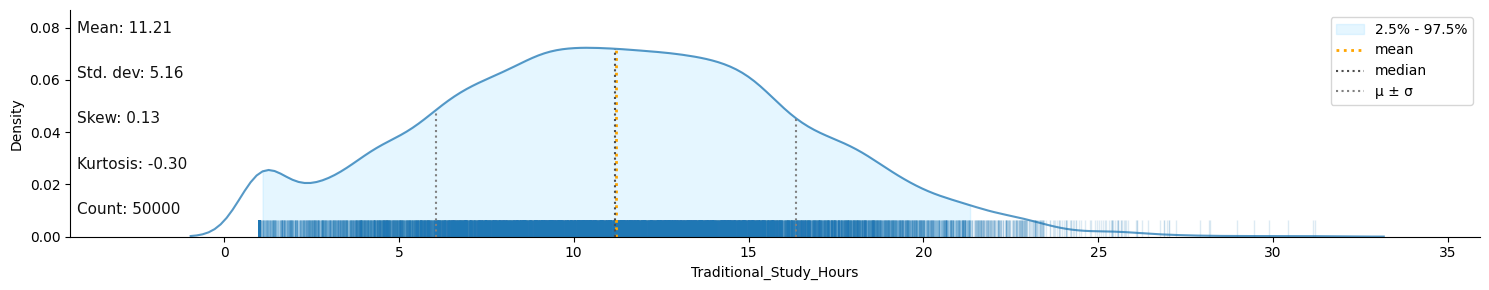

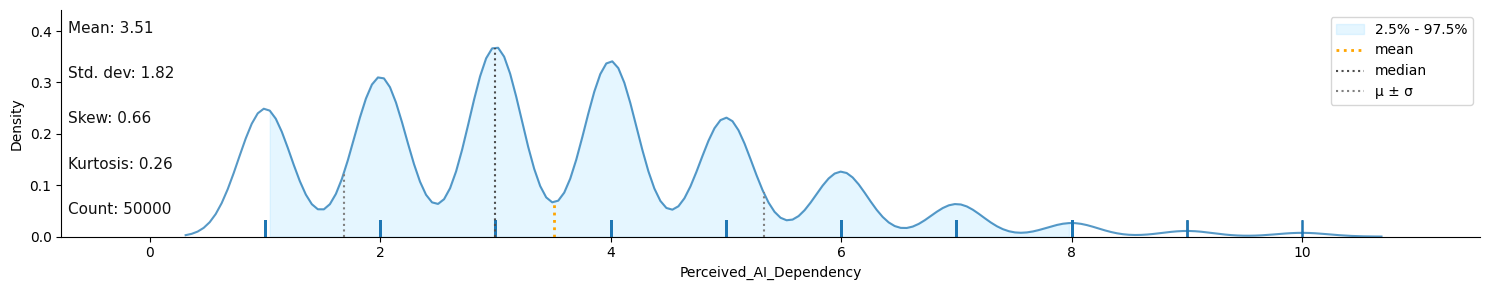

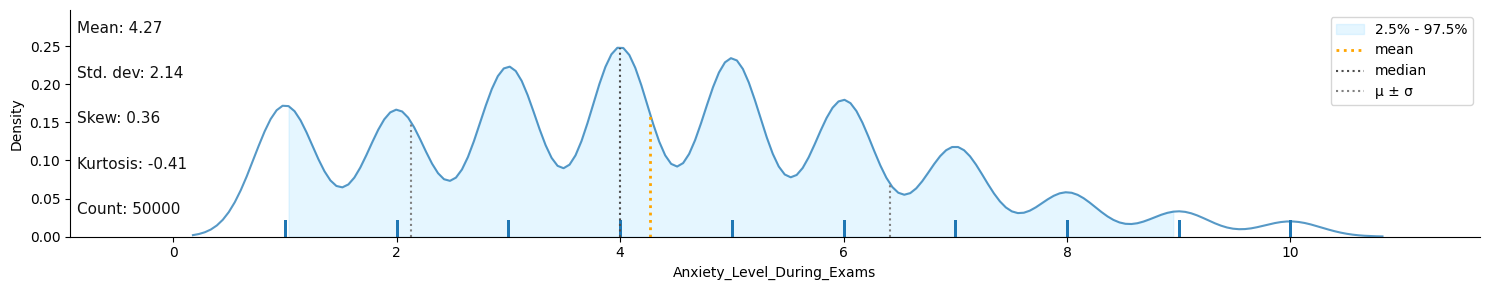

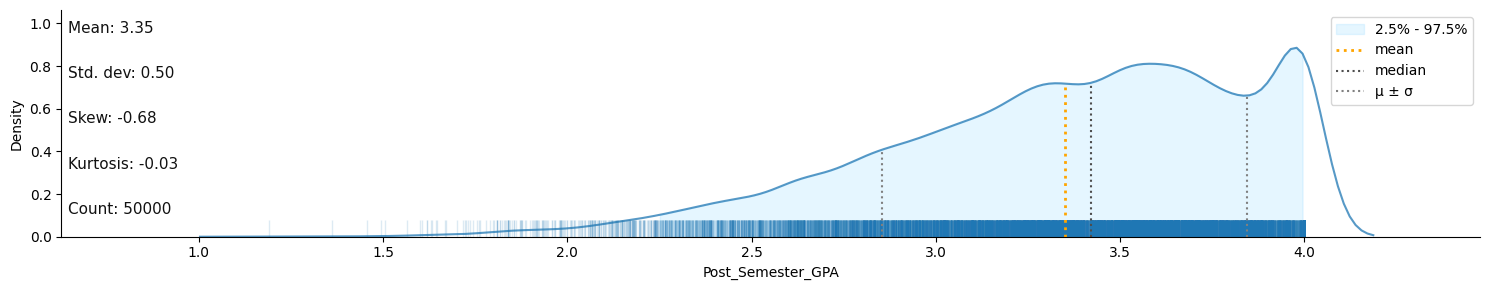

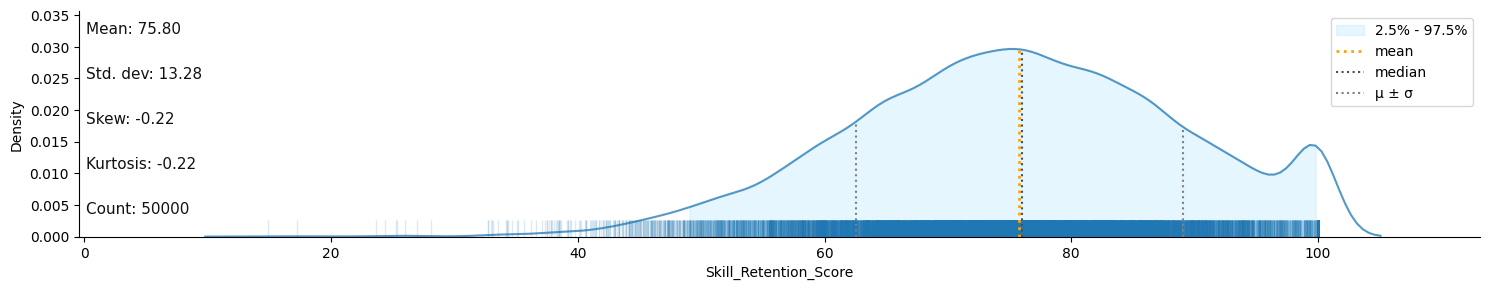

In [ ]:
# ============================================================
# KLIB — Distribution Plot
# UZ: Raqamli ustunlarning taqsimotini ko'rsatadi
# EN: Shows distribution of numerical columns
# ============================================================
if KLIB_AVAILABLE:
    klib.dist_plot(df.select_dtypes(include=[np.number]))
# df.select_dtypes(include=[np.number]) - faqat sonli ustunlarni tanlaydi   
# klib.dist_plot(...) - har bir numeric ustun uchun:histogram, distribution graph chizadi.


# Dataset juda katta bo'lgani uchun grafik chizishda faqat 10,000 ta tasodifiy namunadan foydalanildi. Lekin statistik hisoblar butun dataset asosida hisoblanadi.
# Large dataset detected, using 10000 random samples for the plots. Summary statistics are still based on the entire dataset.

In [ ]:
# ============================================================
# KORRELYATSIYA MATRITSASI — df.corr()
# ============================================================
# df.corr() - ustunlar orasidagi statistik bog'liqlikni hisoblaydi.
#  Qiymat -1 dan 1 gacha:
#   +1 = to'liq musbat bog'liqlik
#   -1 = to'liq manfiy bog'liqlik
#    0 = bog'liqlik yo'q
#     QAYERDA ishlatiladi: Feature selection uchun, preprocessing dan OLDIN yoki KEYIN. Qaysi featurelar target bilan kuchli bog'liq ekanini bilish uchun.

# df.corr() computes correlation between columns (-1 to +1).
#  WHERE: For feature selection, BEFORE or AFTER preprocessing.
#  To know which features are strongly related to the target.

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

print("Korrelyatsiya Matritsasi / Correlation Matrix:")
print(corr.round(3))        # round(3) - sonlarni 3 ta kasr xonasigacha yaxlitlaydi

Korrelyatsiya Matritsasi / Correlation Matrix:
                            Student_ID  Pre_Semester_GPA  Weekly_GenAI_Hours  \
Student_ID                       1.000             0.002               0.002   
Pre_Semester_GPA                 0.002             1.000              -0.001   
Weekly_GenAI_Hours               0.002            -0.001               1.000   
Tool_Diversity                  -0.001            -0.006               0.008   
Traditional_Study_Hours          0.001            -0.005              -0.157   
Perceived_AI_Dependency          0.003             0.001               0.665   
Anxiety_Level_During_Exams       0.010            -0.001               0.269   
Post_Semester_GPA               -0.001             0.927              -0.019   
Skill_Retention_Score           -0.002             0.099              -0.118   

                            Tool_Diversity  Traditional_Study_Hours  \
Student_ID                          -0.001                    0.001   
Pre_Semest

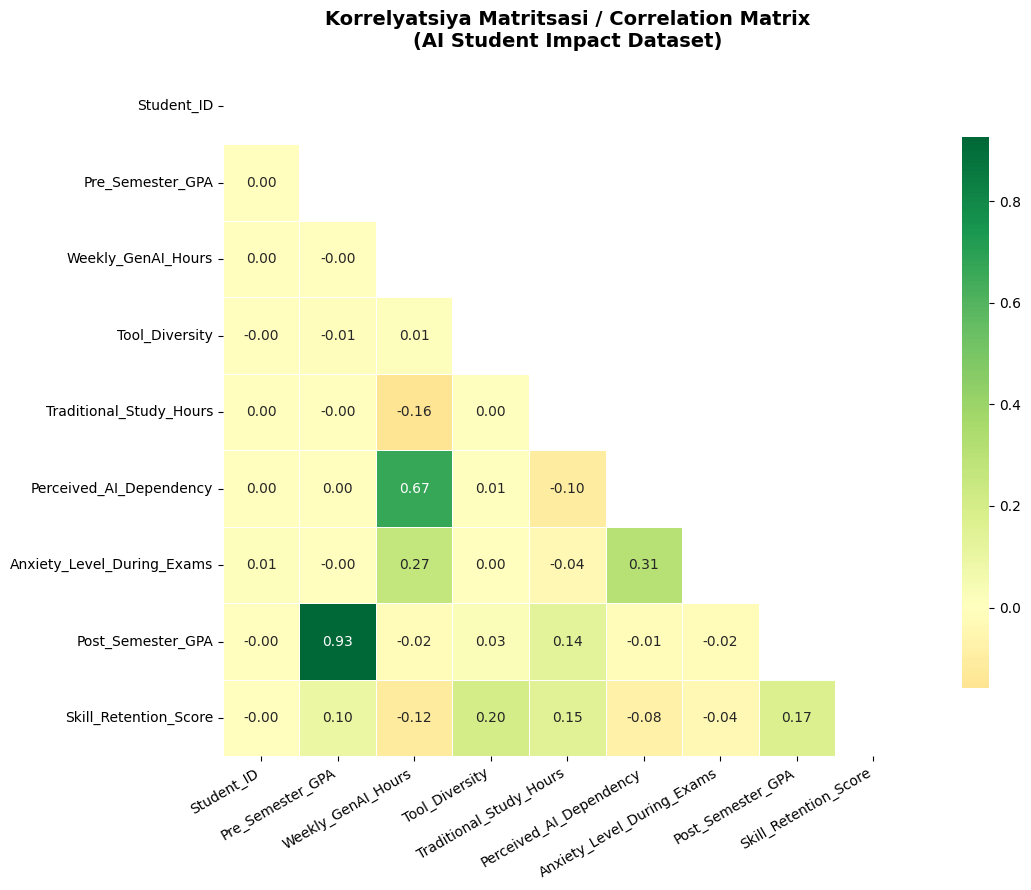

In [ ]:
        # --- Korrelyatsiya matritsasini vizual ko'rinishi ---
plt.figure(figsize=(12, 9))             # Grafik oynasi hajmini beradi(width=12, height=9)
mask = np.triu(np.ones_like(corr, dtype=bool))
# Korrelyatsiya matritsasi simmetrik bo'ladi. Masalan( a<>b = b<>a). Keraksiz qism(heatmapning yarmini yashiradi, grafikni toza qiladi)
sns.heatmap(                            # sns.heatmap(...) - asosiy grafika
            corr,                       # corr(parametr) - Korrelyatsiya matrix
            annot=True,                 # annot=True - Har katak ichida son yozadi
            fmt='.2f',                  # fmt='.2f' - Sonlarni yag'litlaydi (2 decimal 0.8134 => 0.81)
            cmap='RdYlGn',              # cmap='RdYlGn' - rang sxemasi (Red → negative, Yellow → neutral, Green → positive)
            center=0,                   # center=0 - 0ni markaz qiladi (negative va positive correlationlarni aniqroq ko‘rsatadi)
            mask=mask,                  # mask=mask - Yuqori yarmini yashiradi
            linewidths=0.5,             # linewidths=0.5 - Kataklar orasiga chiziq qo'shadi
            square=True,                # square=True - Kataklarni kvadrat qiladi
            cbar_kws={'shrink': 0.8})   # cbar_kws={'shrink': 0.8} - Yonidagi colorbarni kichraytiradi
plt.title('Korrelyatsiya Matritsasi / Correlation Matrix\n(AI Student Impact Dataset)',         # plt.title(...) - sarlavha qo'shish(Grafik nomi)
          fontsize=14, fontweight='bold', pad=15)
                                        # fontsize=14 - sarlavha yozuvining kattaligini belgilaydi(matn hajmi)
                                        # fontweight='bold' - yozuvni qalin qiladi
                                        # pad=15 - title bilan grafik orasidagi masofani beradi

plt.xticks(rotation=30, ha='right')     # plt.xticks(...) - Ustun nomlari
                                        # rotation=30 - 30gradus aylantiradi
                                        # ha='right' - ha(horizontal alignment) bu matnni o‘ng tomonga tekislaydi (right alignment)

plt.tight_layout()                      # plt.tight_layout() - Elementlar bir-biriga yopishib ketmasligi uchun

plt.savefig(os.path.join('data_analysis', '01_correlation_matrix.png'), dpi=150, bbox_inches='tight')
# plt.savefig(...) - Heatmap PNG fayl bo‘lib saqlanadi
# dpi=150 - bu rasmning sifatini (resolution) belgilaydi -> dpi(Dots Per Inch-1 inch ichida nechta nuqta (pixel) ishlatilishini bildiradi)
# bbox_inches='tight' - bu rasmni saqlayotganda ortiqcha bo‘sh joylarni kesib tashlaydi

plt.show()          # plt.show() - headmapni ekranda ko'rsatadi(Grafik chiqarish)


In [ ]:
# Post_Semester_GPA bilan korrelyatsiya
# Correlation with Post_Semester_GPA
print("\n Post_Semester_GPA bilan korrelyatsiya / Correlation with Post_Semester_GPA:")
print(corr['Post_Semester_GPA'].sort_values(ascending=False))
    # corr['Post_Semester_GPA'] - faqat Post_Semester_GPA bilan bog‘liq korrelyatsiyalarni oladi
    # .sort_values(ascending=False) - natijalarni (katta → kichik, descending order) bo'yicha saralaydi


 Post_Semester_GPA bilan korrelyatsiya / Correlation with Post_Semester_GPA:
Post_Semester_GPA             1.000000
Pre_Semester_GPA              0.926781
Skill_Retention_Score         0.169616
Traditional_Study_Hours       0.137653
Tool_Diversity                0.025265
Student_ID                   -0.000602
Perceived_AI_Dependency      -0.014180
Anxiety_Level_During_Exams   -0.015909
Weekly_GenAI_Hours           -0.018600
Name: Post_Semester_GPA, dtype: float64


---
## Dublikat qatorlar (Duplicates)

In [ ]:
# ============================================================
# Duplacated = takrorlanuvchi qatorlar
# ============================================================
#   Duplikat qatorlar - bir xil ma'lumorlar bir necha marta kiritilgan.
#   Preprocessing bosqichining Birinchi qismida tekshirilishi kerak!
#   Nima uchun zararli: Model bir xil narsani ko'p ko'rib overfitting qiladi.
#
#   Duplicate rows - same data entered multiple times.
#   Must be checked at the Very Beginning of preprocessing!
#   Why harmful: Model sees same thing too many times -> overfitting.

print("=" * 60)
print("Dublikat tahlili / Duplicate Analysis")
print("=" * 60)

# 1. Umumiy dublikatlar
n_dup = df.duplicated().sum()
print(f"\n1. Umumiy dublikatlar / Total duplicates: {n_dup}")

# 2. Duplikatlarni ko'rish (mavjud bo'lsa)
if n_dup > 0:
    print("\n2. Dublikat qatorlar:")
    print(df[df.duplicated(keep='first')].head())
        # df.duplicated(...) - qaysi qator takrorlanganini tekshiradi
        # keep='first' - birinchi uchragan qatorni saqlaydi, keyingi aynan bir xil qatorlarni duplicate deb belgilaydi
    # O'chirish / Remove
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
        # drop_duplicates(...) - takrorlangan qatorlarni o‘chiradi
        # drop_duplicates(keep='first') - birinchi qatorni qoldiradi
        # .reset_index(drop=True) - Indexni qayta tartiblaydi
    print(f"   Dublikatlar o'chirildi. Yangi shape: {df.shape}")
        # Datasetning yangi o‘lchamini chiqaradi
else:
    print("   Dublikat qator topilmadi! / No duplicate rows found!")

Dublikat tahlili / Duplicate Analysis

1. Umumiy dublikatlar / Total duplicates: 0
   Dublikat qator topilmadi! / No duplicate rows found!


---
## Missing Values - Yo'q qiymatlar

In [ ]:
# ============================================================
# MISSING VALUES TAHLILI
# ============================================================
#   Yo'q qiymatlarni (NaN) - Ma'lumot kiritilmagan joylar
#   5 ta usul bilan to'ldirish yoki o'chirish mumkin
#   Missing values (NaN) - places where data was not entered
#   Can be handled with 5 methods

print("=" * 60)
print("Missing Values Tahlili / Analysis")
print("=" * 60)

    # --- Missing Values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
# missing_pct - datasetdagi bo‘sh qiymatlar necha foiz ekanligini topadi

missing_df = pd.DataFrame({             # pd.DataFrame(...) - yangi jadval yaratadi
    'Ustun / Column': missing.index,    # missing.index - ustun nomlarini oladi
    'Soni / Count': missing.values,     # missing.values - missing sonlarini oladi
    'Foiz / Percent(%)': missing_pct.values.round(2)  # missing_pct.values.round(2) - missing foizlarini oladi(va 2 decimalgacha yaxlitlaydi)
})
print(missing_df.to_string(index=False))              # bu kod missing_df jadvalini indexsiz to‘liq matn ko‘rinishida chiqaradi

# prints the dataframe as a clean text table without row index numbers
# to_string() → converts dataframe to formatted text
# index=False → hides row indices
# Useful for readable console reports

total_missing = missing.sum()
print(f"\nJami missing / Total missing: {total_missing}")

if total_missing == 0:
    print("Bu datasetda yo'q qiymatlar mavjud emas")

Missing Values Tahlili / Analysis
            Ustun / Column  Soni / Count  Foiz / Percent(%)
                Student_ID             0                0.0
            Major_Category             0                0.0
             Year_of_Study             0                0.0
          Pre_Semester_GPA             0                0.0
        Weekly_GenAI_Hours             0                0.0
          Primary_Use_Case             0                0.0
  Prompt_Engineering_Skill             0                0.0
            Tool_Diversity             0                0.0
         Paid_Subscription             0                0.0
   Traditional_Study_Hours             0                0.0
   Perceived_AI_Dependency             0                0.0
      Institutional_Policy             0                0.0
Anxiety_Level_During_Exams             0                0.0
         Post_Semester_GPA             0                0.0
     Skill_Retention_Score             0                0.0
      

In [ ]:
# ============================================================
# Missing Values - 5 ta usul(mean,median,mode,fixed,drop)
# ============================================================

# Demo uchun sun'iy NaN qo'shamiz / Add artificial Nan for demo
df_demo = df.copy()         # dataset nusxasi olinadi(original datasetni saqlab qoladi,o'zgarishlar faqat df_demo da bo'ladi)
np.random.seed(42)          # NumPydagi random generatorni bir xil natija beradigan qiladi(Har safar bir xil random indexlar chiqadi. Bu reproducibility uchun muhim.)

nan_idx_num = np.random.choice(df_demo.index, size=500, replace=True)
# numeric ustundan 500 ta random qator tanlaydi / replace=False - bir index ikki marta tanlanmaydi

nan_idx_cat = np.random.choice(df_demo.index, size=300, replace=False)
# categorical ustundan 300 ta random qator tanlaydi / replace=False - bir index ikki marta tanlanmaydi

df_demo.loc[nan_idx_num, 'Weekly_GenAI_Hours'] = np.nan
# numeric ustunga NaN qo'yish(tanlangan 500 qatorda: 'Weekly_GenAI_Hours' ustunini bo'sh qiladi)

df_demo.loc[nan_idx_num[:300], 'Pre_Semester_GPA'] = np.nan
# yana bir numeric ustunga NaN(500 ta indexning - birinchi 300 tasiga NaN qo'yadi)

df_demo.loc[nan_idx_cat, 'Major_Category'] = np.nan
# categorical ustunga NaN qo'yish(tanlangan 300 ta qatorda: 'Major_Category' ustunini bo'sh qiladi)

df_demo.loc[nan_idx_cat[:150], 'Burnout_Risk_Level'] = np.nan
# yana bir categorical ustunga NaN(300 ta indexning - birinchi 150 tasiga NaN qo'yadi) 

print("Demo NaN qo'shilgandan keyin / After adding demo NaN:")
print(df_demo[['Weekly_GenAI_Hours','Pre_Semester_GPA',
                'Major_Category','Burnout_Risk_Level']].isnull().sum())
                # Missing sonlarini chiqarish - har ustunda nechta NaN borligini chiqaradi

Demo NaN qo'shilgandan keyin / After adding demo NaN:
Weekly_GenAI_Hours    500
Pre_Semester_GPA      300
Major_Category        300
Burnout_Risk_Level    150
dtype: int64


In [ ]:
        # ---- 1. MEAN bilan to'ldirish / Fill with MEAN ----
    # O'rtacha arifmetik mean. Raqamli ustublar uchun, outlier(datasetdagi boshqa qiymatlardan juda uzoq yoki noodatiy qiymat) kam bo'lganda
    # Arithmetic mean. For numerical columns, when outliers are few
df_mean = df_demo.copy()
mean_val = df_mean['Weekly_GenAI_Hours'].mean()
df_mean['Weekly_GenAI_Hours'].fillna(mean_val, inplace=True)
print(f"\n1. Mean: Weekly_GenAI_Hours mean = {mean_val:.2f}")

    # -- Meanni qisqaroq yozilishi --
#df_mean['Weekly_GenAI_Hours'] = (
#    df_mean['Weekly_GenAI_Hours']
#    .fillna(df_mean['Weekly_GenAI_Hours'].mean())
#)


1. Mean: Weekly_GenAI_Hours mean = 8.43


In [ ]:
        # ---- 2. MEDIAN bilan to'ldirish / Fill with MEDIAN ----
    # O'rtacha qiymat. Outlier ko'p bo'lganda Mean dan yaxshiroq
    # Middle value. Better than Mean when many outliers exist
df_median = df_demo.copy()
median_val = df_median['Pre_Semester_GPA'].median()
df_median['Pre_Semester_GPA'].fillna(median_val, inplace=True)
print(f"2. Median: Pre_Semester_GPA median = {median_val:.2f}")

    # -- Medianni qisqaroq yozilishi --
#df_median['Pre_Semester_GPA'] = (
#    df_median['Pre_Semester_GPA']
#    .fillna(df_median['Pre_Semester_GPA'].median())
#)

2. Median: Pre_Semester_GPA median = 3.21


In [ ]:
        # ---- 3. MODE bilan to'ldirish / Fill with MODE ----
    # Eng ko'p takrorlanuvchi qiymat. Kategorik ustunlar uchun
    # Most frequent value. For categorical columns
df_mode = df_demo.copy()
mode_val = df_mode['Major_Category'].mode()[0]
df_mode['Major_Category'].fillna(mode_val, inplace=True)
print(f"3. Mode: Major_Category mode = '{mode_val}'")

    # -- Modeni qisqaroq yozilishi --
#df_mode['Major_Category'] = (
#    df_mode['Major_Category']
#    .fillna(df_mode['Major_Category'].mode()[0])
#)

3. Mode: Major_Category mode = 'STEM'


In [ ]:
        # ---- 4. FIXED qiymat / Fill with FIXED values ----
    # O'zingiz belgilagan qiymat. Biznes mantiqiga asosan
    # Value you specify. Based on business logic
df_fixed = df_demo.copy()
df_fixed['Burnout_Risk_Level'].fillna('Unknown',inplace=True)
print(f"4. Fixed: Burnout_Risk_Level 'Unknown' bilan to'ldirildi")

    # -- Fixedni qisqaroq yozilishi --
#df_fixed['Burnout_Risk_Level'] = (
#    df_fixed['Burnout_Risk_Level']
#    .fillna('Unknown')
#)

4. Fixed: Burnout_Risk_Level 'Unknown' bilan to'ldirildi


In [ ]:
        # ---- 5. DROP - Qatorni o'chirish / Remove rows ----
    # Yo'q qiymatli qatorni butunlay o'chiradi
    # Faqat juda kam missing value bo'lganda ishlatish (<5%)!
    # Completely removes rows with missing values
    # Use only when very few missing values exist (<5%)!
df_drop = df_demo.copy()
before_drop = len(df_drop) # df_drop datasetidagi qatorlar sonini hisoblab,before_drop ga saqlaydi
df_drop.dropna(inplace=True)
after_drop = len(df_drop)
print(f"5. Drop: {before_drop - after_drop} qator o'chirildi / rows removed")
print(f" Eski shape: {before_drop} -> Yangi shape: {after_drop}")

print("\n Haqiqiy datasetda missing yo'q / Real dataset has no missing")

    # -- Dropni qisqaroq yozilishi --
#df_drop = df_demo.dropna().copy()
#before_drop = len(df_demo)
#after_drop = len(df_drop)

5. Drop: 795 qator o'chirildi / rows removed
 Eski shape: 50000 -> Yangi shape: 49205

 Haqiqiy datasetda missing yo'q / Real dataset has no missing


---
## Encoding - Kategorik Ustunlarni Raqamlashtirish

In [ ]:
# ============================================================
# ENCODING turlari
# ============================================================

# Bizning kategorik ustunlar / Our categorical columns:
cat_cols = df.select_dtypes(include=['object','str','bool']).columns.tolist()
print("Kategorik ustunlar / Categorical columns:", cat_cols)

print("\n" + "="*60)
print("Encoding usullari / Encoding methods")
print("="*60)

sample = df[['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
             'Paid_Subscription', 'Institutional_Policy', 'Burnout_Risk_Level']].head(6).copy()

Kategorik ustunlar / Categorical columns: ['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy', 'Burnout_Risk_Level']

Encoding usullari / Encoding methods


In [ ]:
        # ---- 1. LABEL Encoding ----
    # Har bir kategoriyaga raqam beradi (0dan boshlab)
    # Assigns numbers to each category (starting from 0)
    # Qachon: Tree-based modellar uchun (Decision Tree, Random Forest)
    # When: For Tree-based models (Decision Tree, Random Forest)
    # Kamchiligi: Linear modellar uchun noto'g'ri (2 > 1 deb hisoblaydi)
    # Disadvantage: Wrong for Linear models (implies 2 > 1)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le_result = sample.copy()
le_result['Major_LabelEnc'] = le.fit_transform(sample['Major_Category'])
print("\n1. Label Encoding - Major_Category:")
print(le_result[['Major_Category','Major_LabelEnc']].drop_duplicates())
    # .drop_duplicates() -> takroriy qatorlarni olib tashlaydi
print(f" Classes: {le.classes_}")   # qaysi categorical qiymatlar qanday tartibda encode qilinganini ko‘rsatadi


1. Label Encoding - Major_Category:
  Major_Category  Major_LabelEnc
0     Humanities               1
1        Medical               2
2       Business               0
4           STEM               3
 Classes: ['Business' 'Humanities' 'Medical' 'STEM']


In [ ]:
        # ---- 2. ONE-HOT Encoding ---
    # Har bir kategoriya uchun yangi ustun (0 va 1)
    # New column for each category (0 or 1)
    # Qachon: Linear, Logistic Regression uchun. Kategoriyalar orasida tartib yo'q bo'lganda
    # When: For Linear, Logistic Regression. When no order between categories
    # Kamchiligi: Ko'p kategoriya = ko'p ustun (dimensionality problem)
    # Disadvantage: Many categories = manu columns (dimensionality problem)

oh_result = pd.get_dummies(sample[['Major_Category']],prefix='Maj', drop_first=False)
    # Bu qator Major_Category ustunini One-Hot Encoding qiladi.
        # pd.get_dummies(...) -> categorical (object) ma’lumotlarni 0 va 1 ustunlarga aylantirish
        # sample[['Major_Category']] -> Bu sample dataframe ichidan Major_Category ustunini oladi
        # Nega [[' ']] ishlatilgan? -> sample[['Major_Category']]->(DataFrame qaytaradi) / sample['Major_Category']->(Series qaytaradi)
        # get_dummies bilan ishlaganda DataFrame ishlatish qulayroq
        # prefix='Maj' -> yangi ustun boshiga 'Maj' qo'shadi
        # drop_first=False -> False bo'lsa(HAMMA kategoriya ustun bo'ladi) / True bo'lsa(Birinchi kategoriya tashlab yuboriladi)

print("\n2. One-Hot Encoding - Major_Category:")

print(pd.concat([sample['Major_Category'],oh_result],axis=1).drop_duplicates())
    # Bu qator encoding natijasini original ustun bilan birga chiqaradi
        # pd.concat([...], axis=1) -> bir nechta ustunni yonma-yon birlashtiradi
        # sample['Major_Category'] -> original ustun
        # oh_result -> Encoded ustunlar
        # axis=1 -> yoniga qo'shadi (ustun bo'yicha)
        # .drop_duplicates() -> takroriy qatorlarni olib tashlaydi


2. One-Hot Encoding - Major_Category:
  Major_Category  Maj_Business  Maj_Humanities  Maj_Medical  Maj_STEM
0     Humanities         False            True        False     False
1        Medical         False           False         True     False
2       Business          True           False        False     False
4           STEM         False           False        False      True


In [ ]:
        # ---- ORDINAL Encoding ----
    # Tartibli kategoriyalar uchun - tartibni saqlab raqam beradi
    # For ordered categories - assigns numbers preserving order
     # Qachon: Year_of_Study (Freshman < Sophomore < Junior < Senior < Graduate) kabi
     # When: Like Year_of_Study (Freshman < Sophomore < Junior < Senior < Graduate)
    # Ordinal Encoding -> Tartib asosida sonlarga aylantirish
year_order = [['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']]
    # Bu yerda kategoriyalar tartibi berilgan

oe = OrdinalEncoder(categories=year_order)
    # Bu yerda OrdinalEncoder obyekti yaratilmoqda
    # categories=year_order -> Encoderga mana shu tartibda encode qil deb aytyapmiz
    # Agar categories=year_order yozmasak ->  encoder avtomatik alphabetical tartib qiladi

ord_result = sample.copy()
    # sample dataframe nusxasi olinmoqda va ord_resultga saqlanmoqda

ord_result['Year_OrdinalEnc'] = oe.fit_transform(sample[['Year_of_Study']]).astype(int)
    # sample[['Year_of_Study']] -> encoding qilinadigan ustun
    # oe.fit_transform(...) -> 1.fit(kategoriyalarni o'rganadi) / 2.transform(qiymatlarni sonlarga aylantiradi)
    # Default natija float bo'ladi -> .astype(int) shuning uchun intga o'zgartirib olamiz
    # ord_result['Year_OrdinalEnc'] = ... ---> encoded qiymatlar yangi ustunga yoziladi
     
print("\n3. Ordinal Encoding - Year_of_Study:")

print(ord_result[['Year_of_Study', 'Year_OrdinalEnc']].drop_duplicates().sort_values('Year_OrdinalEnc'))
    # .drop_duplicates() -> takroriy qatorlarni olib tashlaydi
    # .sort_values('Year_OrdinalEnc') -> encoded qiymat bo‘yicha tartiblaydi


3. Ordinal Encoding - Year_of_Study:
  Year_of_Study  Year_OrdinalEnc
2      Freshman                0
4     Sophomore                1
1        Junior                2
0        Senior                3


In [ ]:
        # ---- BINARY Encoding (Manual) ----
    # Avval label enc, so'ng ikkilikka aylantiradi. Ko'p kategoriya bo'lganda yaxshi
    # First label enc, then binary. Good when many categories exist


In [ ]:
        # ---- TARGEt Encoding ----
    # Kategoriyani o'sha kategoriyaning target qiymatlarining o'rtachasi bilan almashtiradi
    # Replaces category with mean of targetr for that category
     # Xavf: Data leakage - faqat Train data da qo'llang!
     # Risk: Data leakage - apply Only on training data!
print("\n4. Target Encoding - Major_Category -> Post_Semester-GPA:")
target_map = df.groupby('Major_Category')['Post_Semester_GPA'].mean()
        # df.groupby('Major_Category') -> DataFrame'ni Major_Category bo'yicha guruhlaydi
        # ['Post_Semester_GPA'] -> Faqat target ustunni tanlayapti

print(target_map.round(3))
        # .round(3) -> verguldan keyin 3xona yaxlitlaydi


4. Target Encoding - Major_Category -> Post_Semester-GPA:
Major_Category
Arts          3.344
Business      3.336
Humanities    3.346
Medical       3.353
STEM          3.363
Name: Post_Semester_GPA, dtype: float64


In [ ]:
        # ---- FREQUENCY Encoding ----
    # Kategoriyani o'sha kategoriya datasetda necha marta qatnashgani bilan almashtiradi
    # Replaces category with how frequently it appears in the dataset
     # Har bir kategoriyaning soni hisoblanadi
     # Counts occurrences of each category
print("\n5. Frequency Encoding - Major_Category:")
freq_map = df['Major_Category'].value_counts()
    # .value_counts() -> har bir kategoriya necha marta qatnashganini hisoblaydi

print(freq_map)

    # Agar mapping ko'rinishida Encode qilmoqchi bo'lsak:
    # If we want encoded mapping format:
df['Major_FreqEnc'] = df['Major_Category'].map(freq_map)
    # .map(freq_map) -> har bir kategoriyani uning frequency qiymati bilan almashtiradi

print("\n5. Frequency Encoded Result:")
print(df[['Major_Category','Major_FreqEnc']].drop_duplicates().sort_values('Major_FreqEnc'))
    # .drop_duplicates() -> takroriy qatorlarni olib tashlaydi
    # .sort_values('Major_FreqEnc') -> frequency bo'yicha tartiblaydi


5. Frequency Encoding - Major_Category:
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

5. Frequency Encoded Result:


  Major_Category  Major_FreqEnc
7           Arts           5933
1        Medical           6476
0     Humanities           9994
2       Business          12538
4           STEM          15059


---
## Scaling - Ma'lumotlarni Miqyoslashtirish

In [ ]:
# ============================================================
# SCALING turlari
# ============================================================

    # Scaling - turli o'lchovdagi raqamli ustunlarni bir xil miqyosga keltirish
    # Scaling - brings numerical columns with different ranges to same scale
     # Nima uchun: Pre_GPA (0-4) vs Weekly_Hours (0-100) bo'lsa,
     # Model Hours ga ko'proq e'tibor beradi. Scaling bu muammoni hal qiladi
     # Why: If Pre_GPA (0-4) vs Weekly_Hours (0-100), model pays more attention to Hours.
     # Scaling fixes this

num_cols_demo = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours',
                  'Post_Semester_GPA', 'Skill_Retention_Score']

scale_sample = df[num_cols_demo].head(200).copy()
    # df[num_cols_demo] -> faqat tanlagan numerical ustunlarni oladi
    # head(200) -> boshidan 200 qatorni oladi

print("Scaling oldidagi range / Range before scaling:")

print(df[num_cols_demo].agg(['min','max','mean','std']).round(2))
    # .agg([...]) -> (Aggregation function) Bir nechta statistikani bir vaqtda hisoblaydi
    # ['min','max','mean','std'] -> hisoblanadigan statistikalar

Scaling oldidagi range / Range before scaling:
      Pre_Semester_GPA  Weekly_GenAI_Hours  Traditional_Study_Hours  \
min               1.18                0.00                     1.00   
max               4.00               40.00                    35.86   
mean              3.15                8.43                    11.21   
std               0.48                8.27                     5.16   

      Post_Semester_GPA  Skill_Retention_Score  
min                1.00                  10.78  
max                4.00                 100.00  
mean               3.35                  75.80  
std                0.50                  13.28  


In [ ]:
        # ---- STANDARD Scaler ----
    # (x - mean) / std -> Mean=0, Std=1. Normal taqsimot va SVM, Linear modellarda
    # (x - mean) / std -> Mean=0, Std=1. NOrmat distribution, SVM, Linear models
ss = StandardScaler()   # (Standardization) -> Maqsad: barcha numerical ustunlarni bir xil scale’ga olib kelish

scaled_std = pd.DataFrame(ss.fit_transform(scale_sample), columns=num_cols_demo)
    # ss.fit_transform(scale_sample) -> 1.fit(har bir ustunning mean, std qiymatini o'rganadi) / 2.transform(formula orqali scale qiladi)
    # fit_transform() natijasi dataframe emas shuning uchun pd.DataFrame(...) bilan dataframega aylantirilmoqda
    # columns=num_cols_demo -> original column nomlarini qaytaradi / aks holda raqam bo'lib qoladi(0,1,2...)

print("\n1. Standard Scaler (mean≈0, std≈1):")

print(scaled_std.describe().loc[['mean','std']].round(3))
    # scaled_std.describe() -> statistik ma'lumot beradi
    # loc[['mean','std']] -> Faqat mean, std qatorlarini oladi

        # StandardScaler qachon ishlatiladi?
    # Logistic Regression / KNN / SVM


1. Standard Scaler (mean≈0, std≈1):
      Pre_Semester_GPA  Weekly_GenAI_Hours  Traditional_Study_Hours  \
mean             0.000               0.000                    0.000   
std              1.003               1.003                    1.003   

      Post_Semester_GPA  Skill_Retention_Score  
mean             -0.000                 -0.000  
std               1.003                  1.003  


In [ ]:
        # ---- MINMAX Scaler ----
    # (X - min) / (max - min) -> 0dan 1gacha. Neural Networks, KNN uchun yaxshi
     # Kamchiligi: Outlier'larda sezgir
    # (X - min) / (max - min) -> 0 to 1. Good for Neural Networks, KNN
     # Disadvantage: Sensitive to outliers
mms = MinMaxScaler()
scaled_mm = pd.DataFrame(mms.fit_transform(scale_sample),columns=num_cols_demo)
print("\n2. MinMax Scaler (0-1):")
print(scaled_mm.describe().loc[['min','max']].round(3))


2. MinMax Scaler (0-1):
     Pre_Semester_GPA  Weekly_GenAI_Hours  Traditional_Study_Hours  \
min               0.0                 0.0                      0.0   
max               1.0                 1.0                      1.0   

     Post_Semester_GPA  Skill_Retention_Score  
min                0.0                    0.0  
max                1.0                    1.0  


In [ ]:
        # ---- ROBUST Scaler ----
    # (x - median) / IQR -> Outlier'larga eng chidamli
    # (x - median) / IQR -> Most robust against Outliers
rs = RobustScaler()
scaled_rob = pd.DataFrame(rs.fit_transform(scale_sample),columns=num_cols_demo)
print("\n3. Robust Scaler (median=0 based, outlier-resistant):")
print(scaled_rob.describe().loc[['mean','std']].round(3))


3. Robust Scaler (median=0 based, outlier-resistant):
      Pre_Semester_GPA  Weekly_GenAI_Hours  Traditional_Study_Hours  \
mean            -0.148               0.299                    0.023   
std              0.683               0.996                    0.745   

      Post_Semester_GPA  Skill_Retention_Score  
mean             -0.106                  0.008  
std               0.688                  0.675  


In [ ]:
        # ---- MAX ABSOLUTE Scaler ----
    # X / max(|X|) -> -1dan 1gacha. Sparse data (NLP) uchun
    # X / max(|X|) -> -1 to 1. For sparse data (NLP)
mas = MaxAbsScaler()
scaled_mas = pd.DataFrame(mas.fit_transform(scale_sample),columns=num_cols_demo)
print("\n4. Max Absolute Scaler (-1 to 1):")
print(f"Min: {scaled_mas.min().round(3).to_dict()}")
    # scaled_mas.min() -> har bir column uchun minimum qiymat
    # .to_dict() -> natijani dictionary qiladi
print(f"Max: {scaled_mas.max().round(3).to_dict()}")
    # scaled_mas.max() -> har bir column uchun maximum qiymat
    # .to_dict() -> natijani dictionary qiladi


4. Max Absolute Scaler (-1 to 1):
Min: {'Pre_Semester_GPA': 0.37, 'Weekly_GenAI_Hours': 0.003, 'Traditional_Study_Hours': 0.04, 'Post_Semester_GPA': 0.336, 'Skill_Retention_Score': 0.42}
Max: {'Pre_Semester_GPA': 1.0, 'Weekly_GenAI_Hours': 1.0, 'Traditional_Study_Hours': 1.0, 'Post_Semester_GPA': 1.0, 'Skill_Retention_Score': 1.0}


In [ ]:
        # ---- NORMALIZER ----
    # Har bir QATOR uchun normalize qiladi (ustun emas!)
     # Text classification, consine similarity uchun
        # consine similarity -> bu ikki matn bir-biriga qanchalik o‘xshashligini o‘lchaydigan usul(ikki vector orasidagi burchakni o‘lchaydi)
    # Normilizes each ROW (not columns!)
     # For text classification, cosine similarity
norm = Normalizer()
scaled_norm = pd.DataFrame(norm.fit_transform(scale_sample),columns=num_cols_demo)
print("\n5. Normalizer (row-wise):")
print(scaled_norm.head(3).round(4))


5. Normalizer (row-wise):
   Pre_Semester_GPA  Weekly_GenAI_Hours  Traditional_Study_Hours  \
0            0.0269              0.2591                   0.0904   
1            0.0534              0.0156                   0.2327   
2            0.0437              0.2734                   0.1331   

   Post_Semester_GPA  Skill_Retention_Score  
0             0.0266                 0.9609  
1             0.0516                 0.9696  
2             0.0450                 0.9506  


---
# Feature va Target ga ajratish

In [ ]:
# ============================================================
# Feature va Target ajratish - Preprocessing dan oldin!
# ============================================================
    # X (features) va y (target) ni preprocessing dan OLDIN ajratish kerak
    # X (features) va y (target) must be separated BEFORE preprocessing

        # Nima uchun aynan shu joyida:
    # 1. Scaler faqat X ga qo'llanadi, y ga EMAS(y ni scale qilsangiz model noto'g'ri natija beradi)
    # 2. Imputer ham faqat X ga ishlaydi. (Imputer -> datasetdagi missing value (NaN, bo'sh qiymat)larni to'ldiruvchi usul yoki tool)
    # 3. train_test_split X va y ni alohida bo'ladi
    # 4. Target Encoding ni leakage bo'lmasligi uchun train X da qo'llash kerak(Data Leakage — model trening vaqtida aslida bilmasligi kerak bo'lgan ma'lumotni bilib qolishi)
    # 5. y ning turi o'zgarmaydi (kateforik yoki raqamli qoladi)

        # WHY here:
    # 1. Scaler applies to X Only, NOT to y (Scaling y gives wrong model output)
    # 2. Imputer also only works on X
    # 3. train_test_split splits X and y separately
    # 4. Needed to prevent data leakage in Target Encoding
    # 5. y's type doesn't change (stays categorical or numerical)

print("Classification - Burnout_Risk_Level ni bashorat qilamiz")
print("Regression - Post_Semester_GPA ni bashorat qilamiz")
print("=" * 60)

Classification - Burnout_Risk_Level ni bashorat qilamiz
Regression - Post_Semester_GPA ni bashorat qilamiz


In [ ]:
        # ---- Classification uchun ----
# Student_ID ni ham olib tashlaymiz (ID hech qanday ma'lumot bermaydi)
 # Remove Student_ID too (ID gives no information)
# Post_Semester_GPA ham target bilan kuchli bog'liq bo'lishi mumkin -> leakage!!!
 # Post_Semester_GPA might cause leakage with classification target

drop_cols_clf = ['Student_ID', 'Burnout_Risk_Level']
X_clf_raw = df.drop(columns=drop_cols_clf)
y_clf = df['Burnout_Risk_Level']

print(f"\nCLASSIFICATION:")
print(f" X shape: {X_clf_raw.shape} <- Features (kirish)")
print(f" y shape: {y_clf.shape} <- Target (chiqish: Burnout_Risk_Level)")
print(f" y classes: {y_clf.unique()}")
    # .unique() -> classlarni nomini chiqaradi (Unique qiymatlar)
print(f" y distribution:\n{y_clf.value_counts()}")
    # .value_counts() -> har bir qiymat necha marta qatnashganini hisoblaydi
    # y distribution: -> target classlar taqsimoti


CLASSIFICATION:
 X shape: (50000, 15) <- Features (kirish)
 y shape: (50000,) <- Target (chiqish: Burnout_Risk_Level)
 y classes: <StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str
 y distribution:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


In [ ]:
        # ---- Regression uchun ----
drop_col_reg = ['Student_ID', 'Post_Semester_GPA']
X_reg_raw = df.drop(columns=drop_col_reg)
y_reg = df['Post_Semester_GPA']

print(f"\nREGRESSION:")     # print(f"...: {...}") -> Formatted string
print(f" X shape: {X_reg_raw.shape} <- Features")
print(f" y shape: {y_reg.shape} <- Target (Post_Semester_GPA)")
print(f" y range: {y_reg.min():.2f} - {y_reg.max():.2f}, mena: {y_reg.mean():.2f}")
    # y range: -> qiymatlar oralig'i


REGRESSION:
 X shape: (50000, 15) <- Features
 y shape: (50000,) <- Target (Post_Semester_GPA)
 y range: 1.00 - 4.00, mena: 3.35


---
## Preprocessing + Funksiya

In [ ]:
# ============================================================
# Preprocessing + FUNCTION
#   Missing values (mean/mode) + Encoding (label/onehot) + Scaling (minmax)
# ============================================================

def preprocess_data(X):
    """
    Dataset ni preprocessing qilish

    Parameters:
    -----------
    X: DataFrame - feature'lar

    Returns:
    -----------
    X: DataFrame - preprocessed
    """
    X = X.copy()

    # --- STEP 1: MISSING VALUES + FUNCTION ---
        # Raqamli uchun Mean, Kategorik uchun Mode
        # For Numerical: Mean, for Categorical: Mode
    for col in X.columns:
        if X[col].isnull().any():
            if X[col].dtype== 'object':
                X[col] = X[col].fillna(X[col].mode()[0])    # MODE
            else:
                X[col] = X[col].fillna(X[col].mean())       # MEAN

    # --- STEP 2: ENCODING + FUNCTION ---

    encoder = LabelEncoder()

    # Bool ustunlarni avval int ga o'tkazish
    bool_cols = X.select_dtypes(include='bool').columns.tolist()
    for col in bool_cols:
        X[col] = X[col].astype(int)   # True→1, False→0

    # Matnli ustunlarni encode qilish    
    obj_cols = X.select_dtypes(include=['object']).columns.tolist()  # ← oldin ro'yxat olinadi
    for col in obj_cols:                # ← X.columns emas, oldindan olingan ro'yxat
        # if X[col].dtype == 'str' and X[col].dtype == 'bool':
        if X[col].nunique() < 5:
            # OneHot: kam kategoriyali ustunlar uchun
            # Har kategoriya uchun yangi ustun — linear modellar uchun / New column for each category — for linear models
            dummies = pd.get_dummies(X[col], prefix=col, dtype=int)
            X = pd.concat([X.drop(columns=[col]), dummies], axis=1)
        else:
            # Label: ko'p kategoriyali ustunlar uchun
            # Har bir kategoriya uchun raqam — tree-based modellar uchun yaxshi / Number for each category — good for tree-based models
            X[col] = encoder.fit_transform(X[col])

    # --- STEP 3. SCALING(MinMax) + FUNCTION ---
    scaler = MinMaxScaler()
    num_col = X.select_dtypes(include=['int64','float64']).columns
    if len(num_col) > 0:    # len(...) -> num_col ichida ustunlar bormi-yo'qligini tekshiradi
        X[num_col] = scaler.fit_transform(X[num_col])

    return X

# Preprocessing ni qo'llash / Apply preprocessing
print(" Preprocessing boshlandi / Starting preprocessing...")


X_clf = preprocess_data(X_clf_raw)
X_reg = preprocess_data(X_reg_raw)

print(f"\nClassification preprocessed shape: {X_clf.shape}")
# print(X_clf.head(3))

print(f"\nRegression preprocessed shape: {X_reg.shape}")
# print(X_reg.head(3))

    # Preprocessed fayllarni saqlash / Save preprocessed files
X_clf.to_csv(os.path.join('data','preprocessed','X_clf_preprocessed.csv'), index=False)
X_reg.to_csv(os.path.join('data','preprocessed','X_reg_preprocessed.csv'), index=False)
print("\n Preprocessed datasetlar saqlandi! / Preprocessed datasets saved!")

 Preprocessing boshlandi / Starting preprocessing...

Classification preprocessed shape: (50000, 19)

Regression preprocessed shape: (50000, 21)

 Preprocessed datasetlar saqlandi! / Preprocessed datasets saved!


In [ ]:
print(X_clf.columns.tolist())
print(X_reg.columns.tolist())

['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Major_FreqEnc', 'Prompt_Engineering_Skill_Advanced', 'Prompt_Engineering_Skill_Beginner', 'Prompt_Engineering_Skill_Intermediate', 'Institutional_Policy_Actively_Encouraged', 'Institutional_Policy_Allowed_With_Citation', 'Institutional_Policy_Strict_Ban']
['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Skill_Retention_Score', 'Major_FreqEnc', 'Prompt_Engineering_Skill_Advanced', 'Prompt_Engineering_Skill_Beginner', 'Prompt_Engineering_Skill_Intermediate', 'Institutional_Policy_Actively_Encouraged', 'Institutional_Policy_Allowed_With_Citation', 'Institu

---
## Train - Test Split

In [ ]:
# ============================================================
# Train - Test Split
# ============================================================
 # Datasetni 2 qismga bo'lamiz:
 # Split dataset into 2 parts:

    # - Train (80%): Model shu data bilan o'rganadi
    # - Train (80%): Model learns form this data
    # - Test  (20%): Model shu data bilan baholanadi (ko'rmagan data)
    # - Test  (20%): Model is evaluated on this (unseen data)

 # random_state=42 --- har safar bir xil bo'linish (reproducibility)
  # random_state=42 --- Same split every time (reproducibility)
 # stratify=y_clf  --- target klasslar train va test da teng taqsimlansin
                       # (Masalan, High 30% bo'lsa, train va test da ham 30% bo'lsin)
  # stratify=y_clf --- Equal class distribution in train and test

    # --- Classification ---
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf      # Klass nisbatlarini saqlab qolish / Preserve class ratios
)

    # --- Regression ---
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
    # Regression da stratify kerak emas - y raqamli(continuous)
    # No stratify for regression - y is numerical (continuous)
)

print(" Train-Test Split natijalari / Results:")
print(f"\nClassification:")
print(f" X_train: {X_train_clf.shape} X_test: {X_test_clf.shape}")
print(f" y_train: {y_train_clf.shape} y_test: {y_test_clf.shape}")
print(f"  {y_train_clf.value_counts(normalize=True).round(3).to_dict()}")

print(f"\nRegression:")
print(f" X_train: {X_train_reg.shape} X_test: {X_test_reg.shape}")
print(f" y_train: {y_train_reg.shape} y_test: {y_test_reg.shape}")

 Train-Test Split natijalari / Results:

Classification:
 X_train: (40000, 19) X_test: (10000, 19)
 y_train: (40000,) y_test: (10000,)
  {'Medium': 0.423, 'Low': 0.327, 'High': 0.25}

Regression:
 X_train: (40000, 21) X_test: (10000, 21)
 y_train: (40000,) y_test: (10000,)


---
# MODEL Train va Predict

## *Classification Modellar*

In [ ]:
# ============================================================
# CLASSIFICATION Modellar - Train va Predict
# ============================================================

    # 1. Logistic Regression
     # Sigmoid funksiya orqali klassifikatsiya qiladi
     # Classifies via sigmoid function
      # Scaling Kerak: HA - gradient descent ishlatadi, masofaga sezgir
      # Scaling NEEDed: YES - uses gradient descent, sensitive to scale
print(" 1. Logistic Regression o'qitilmoqda...")
lr_clf = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
    # max_iter=1000 -> model maksimum nechta iteration (aylanish) qilishini belgilaydi
    # C=1.0 -> regularization strength’ni boshqaradi
    # regularization -> juda murakkab bo'lib ketishidan saqlaydi (overfittingni kamaytiradi)

lr_clf.fit(X_train_clf, y_train_clf)        # O'qitish / Train
y_pred_lr = lr_clf.predict(X_test_clf)      # Bashorat / Predict
print(f" Tayyor! Accuracy: {accuracy_score(y_test_clf, y_pred_lr):.4f}")

    # 2. Decision Tree Classifier
     # Daraxt shaklida "if/else" qarorlar qabul qiladi.
      # Makes decisions in tree-form if/else rules
     # Scaling kerak EMAS: Chunki u qiymatlarni faqat taqqoslaydi
      # Scaling NOT Needed: Because it only compares values
     # (x <= threshold), arifmetik amal qilmaydi. Scale qilsangiz ham bo'lmasa ham bir xil split topadi
      # (x <= threshold), no arithmetic. Same split found scaled or not
print(" 2. Decision Tree Classifier o'qitilmoqda...")
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_split=20)
    # max_depth=8 -> daraxtning maksimal chuqurligi (depth -> rootdan pastga nechta bosqich tushganini bildiradi)
    # min_samples_split=20 -> node bo‘linishi uchun minimum sample soni (node -> tree ichidagi bo'linish nuqtasi)

dt_clf.fit(X_train_clf, y_train_clf)
y_pred_dt_clf = dt_clf.predict(X_test_clf)
print(f" Tayyor! Accuracy: {accuracy_score(y_test_clf, y_pred_dt_clf):.4f}")

    # 3. Random Forest Classifier
     # Ko'p Decision Tree lardan iborat ensemble. Har biri tasodifiy subset da o'rganadi
      # Ensemble of many DEcision Trees. Each learns on random subset
     # Scaling Kerak EMAS: Tree-based - masofani hisoblamaydi
      # Scaling NOT Needed: Tree-based - no distance computation
     # Afzalligi: Overfitting ga chidamli, juda kuchli model
      # Advantage: Resistant to overfitting, very powerful
print(f" 3. Random Forest Classifier o'qitilmoqda...")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
    # n_estimators=100 -> nechta Decision Tree ishlatilishini bildiradi
    # n_jobs=-1 -> CPU core'larni parallel ishlatadi (1-1core, 2-2core, -1 => barcha core)
    # (n_jobs - model nechta processor ishlatishini bildiradi)
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf)
print(f" Tayyor! Accuracy: {accuracy_score(y_test_clf, y_pred_rf_clf):.4f}")

    # 4. Support Vector Classifier
     # Klass orasidagi maksimal chiziq (hyperplane) topadi
      # Finds maximum margin hyperplane between classes
     # Scaling KERAK: Ha - masofaga asoslangan algoritm
      # Scaling NEEDed: Yes - distance-based algorithm
     # Qachon: O'rta o'lchamdagi dataset, murakkab chegara kerak bo'lganda
      # WHEN: Medium-sized dataset, complex boundary needed
print(" 4. Support Vector Classifier o'qitilmoqda...(katta dataset, sabr qiling)")
svc = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)
 # rbf(Radial Basis Function) - nonlinear classification uchun kernel
 # probability=True qo'ysak: ehtimollik ham hisoblaydi

    # Katta dataset uchun bir subset da o'qitamiz / For long dataset, train on a subset
svc.fit(X_train_clf[:5000],y_train_clf[:5000])
 # X_train_clf[:5000] -> X_traindan faqat birinchi 5000 qatorni oladi
 # y_train_clf[:5000] -> y_traindan faqat birinchi 5000 qatorni oladi.
y_pred_svc = svc.predict(X_test_clf)
print(f" Tayyor! Accuracy: {accuracy_score(y_test_clf, y_pred_svc):.4f}")

 1. Logistic Regression o'qitilmoqda...
 Tayyor! Accuracy: 0.5205
 2. Decision Tree Classifier o'qitilmoqda...
 Tayyor! Accuracy: 0.5181
 3. Random Forest Classifier o'qitilmoqda...
 Tayyor! Accuracy: 0.5319
 4. Support Vector Classifier o'qitilmoqda...(katta dataset, sabr qiling)
 Tayyor! Accuracy: 0.5044


## *Regression Modellar*

### qaytarish

In [ ]:
# ============================================================
# REGRESSION Modellari - Train va Predict
# ============================================================

    # 1. Linear Regression
     # y = w1*x1 + w2*x2 + ... + b formulasi bilan bashorat qiladit
      # Predicts using y = w1*x1 + w2*x2 + ... + b formula
     # Scaling KERAK: Ha - koeffitsientlar optimizatsiyasi uchun
      # Scaling NEEDed: Yes - for coefficient optimization
print(" 1. Linear Regression o'qitilmoqda...")
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_reg)
print(f" Tayyor! R2: {r2_score(y_test_reg, y_pred_lin):.4f}")

    # 2. Decision Tree Regressor
     # Scaling Kerak EMAS! (Classification bilan bir xil sabab)
      # Scaling NOT Needed! (Same reason as classifier)
     # Faqat qiymatlarni taqqoslaydi: x <= threshold
      # Only compares values: x <= threshold
print(" 2. Decision Tree Regressor o'qitilmoqda...")
dt_reg = DecisionTreeRegressor(random_state=42, max_depth=8, min_samples_split=20)
dt_reg.fit(X_train_reg, y_train_reg)
y_pred_dt_reg = dt_reg.predict(X_test_reg)
print(f" Tayyor! R2: {r2_score(y_test_reg, y_pred_dt_reg):.4f}")

    # 3. Random Forest Regressor
     # Scaling Kerak EMAS! Tree-based - masofani hisoblamaydi
      # Scaling NOT Needed! Tree-based - no distance copmutation
print(" 3. Random Forest Regressor o'qitilmoqda...")
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)
print(f" Tayyor! R2: {r2_score(y_test_reg, y_pred_rf_reg):.4f}")

    # 4. Support Vector Regressor
     # Scaling KERAK: HA! Masofaga asoslangan
      # Scaling NEEDed: Yes! Distance-based
print(" 4. Support Vector Regressor o'qitilmoqda... Sabr qiling!")
svr = SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)
    # rbf(Radial Basis Function) -> egri (non-linear) patternlarni o'rganadi
    # C=1.0 -> model qanchalik xatoni kechirishini boshqaradi
    # C -> xatoni qanchalik jiddiy qabul qilish
    # gamma='scale' -> RBF curve(egri chiziq) qanchalik ta'sir qilishini boshqaradi  (Kichik gamma -> ta'sir uzoqroqqa yoyiladi, model soddaroq bo'ladi)
    # 'scale' -> sklearn avtomatik yaxshi qiymat tanlaydi               (Katta gamma -> har nuqta faqat yaqin joyga ta'sir qiladi, model juda murakkablashadi, overfitting)
    # epsilon=0.1 -> kichik xatolarni e'tiborsiz qoldiradi (kichik xatolarni ignore qiladi / noise'ni ignore qiladi / overfitting kamaytiradi)
svr.fit(X_train_reg, y_train_reg)
y_pred_svr = svr.predict(X_test_reg)
print(f" Tayyor! R2: {r2_score(y_test_reg, y_pred_svr):.4f}")

 1. Linear Regression o'qitilmoqda...
 Tayyor! R2: 0.8865
 2. Decision Tree Regressor o'qitilmoqda...
 Tayyor! R2: 0.8813
 3. Random Forest Regressor o'qitilmoqda...
 Tayyor! R2: 0.8967
 4. Support Vector Regressor o'qitilmoqda... Sabr qiling!
 Tayyor! R2: 0.8978


---
## Lasso Regression (L1) and Ridge Regression (L2)

In [ ]:
    # Lasso Regression (L1 Regularization)
     # Linear Regression + |koeffitsient| ni jazolaydigan qo'shimcha term
      # Linear Regression + penalty on absolute coefficients
     # Formula: MSE + alpha * Σ|w|
      # Formula: MSE + alpha * Σ|w|
     # XUSUSIYAT: Ba'zi koeffitsientlarni AYNAN 0 ga keltiradi!
      # FEATURE: Sets some coefficients to EXACTLY 0!
     # Bu avtomati Feature Selection vazifasini bajaradi
      # This automatically performs Featue Selection
     # QACHON: Ko'p feature bor va ahamiyatsizlarini olib tashlash kerak bo'lganda
      # WHEN: Many features, need to eliminate unimportant ones
     # Scaling KERAK: Ha!
      # Scaling NEEDed: Yes!
print(" Lasso Regression (L1) o'qitilmoqda...")
lasso = Lasso(alpha=0.1, random_state=42, max_iter=5000)
    # lasso -> Linear Regression ning kuchaytirilgan versiyasi
        # 1.unnecessary featurelarni kamaytiradi / 2.ba'zilarini 0 qiladi / 3.feature selection qiladi / 4.overfitting kamaytiradi / 5.modelni soddalashtiradi
    # alpha=0.1 -> regularization(juda murakkab bo'lib ketmasligi uchun jazolash) kuchi
        # Katta alpha(=10) -> kuchli regularization /  ko'p coefficientlar 0 bo'ladi / underfitting xavfi
        # Kichik alpha(=0.001) -> deyarli oddiy Linear Regression
lasso.fit(X_train_reg, y_train_reg)
y_pred_lasso = lasso.predict(X_test_reg)
zero_coef = (lasso.coef_ == 0).sum()
print(f" Tayyor! R2: {r2_score(y_test_reg, y_pred_lasso):.4f}")
print(f" L1 da 0 ga teng koeffitsientlar (feature selection): {zero_coef} ta")

    # Ridge Regression (L2 Regularization)
     # Linear Regression + koeffitsientlar kvadratini jazolaydigan term
      # Linear Regression + penalty on squared coefficients
     # Formula: MSE + alpha * Σw²
      # Formula: MSE + alpha * Σw²
     # XUSUSIYAT: Koeffitsientlarni kichraytiradi, lekin 0 qilmaydi
      # Feature: Shrinks coefficients but never to 0
     # Multicollinearity (o'zaro kuchli bog'liq featurelar) bo'lganda yaxshi
      # Good when features are highly correlated (multicollinearity)
     # Korrelyatsiya matritsamizda corr > 0.8 bo'lgan ustunlar bo'lsa ishlatish
      # Use when corr > 0.8 between features
     # Scaling KERAK: Ha!
      # Scaling NEEDed: Yes!
print(" Ridge Regression (L2) o'qitilmoqda...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge.predict(X_test_reg)
print(f" Tayyor! R2: {r2_score(y_test_reg, y_pred_ridge):.4f}")

 Lasso Regression (L1) o'qitilmoqda...
 Tayyor! R2: -0.0002
 L1 da 0 ga teng koeffitsientlar (feature selection): 21 ta
 Ridge Regression (L2) o'qitilmoqda...
 Tayyor! R2: 0.8865


---
# Model EVALUATION

## Classification Evaluation

In [ ]:
# ============================================================
# Classification Evaluation Funksiyasi
# ============================================================

def eval_clf(y_true, y_pred,model_name, y_proba=None):
    print(f"\n{'='*60}")
    print(f" MODEL: {model_name}")
    print('='*60)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')  
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

 # Accuracy
  # To'g'ri bashoratlar / Jami bashoratlar. Balanced dataset uchun yaxshi
  # Correct predictions / Total predictions. Good for balanced dataset
    print(f"\n Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(" Jami to'g'ri bashoratlar foizi / % of all correct prediction")

 # Precision
  # Model 'X klass' dedi - qancha marta haqiqatan to'g'ri edi?
  # Model said 'class X' - how many times was it actually correct?
    print(f"\n Precision: {prec:.4f}")
    print(" Model 'High' dedi - qancha marta to'g'ri / When model said 'High' - how often rihgt")

 # Recall
  # Barcha haqiqiy 'X klass'larning qanchasi to'g'ri topildi?
  # Of all actual 'X class' cases, how many were correctly found?
    print(f"\n Recall: {rec:.4f}")
    print(" Barcha 'High' larning qanchasini topdi / Of all actual 'High' - how many found")

 # F1 Score
  # Precision va Recall harmonik o'rtachasi. Imbalanced dataset da accuracy dan yaxshiroq!
  # Harmonic mean of Precision and Recall. Better than accuracy for imbalanced data!
    print(f"\n F1 Score: {f1:.4}")
    print(" Precision va Recall muvozanati / Balance between Precision and Recall")

 # LOG LOSS
  # Model ehtimolliklarining to'g'rilik darajasi. Kichik bo'lsa yaxshi (0=mukammal)
  # HOw accurate are model's probability predictions. Smaller = better (0=perfect)
    if y_proba is not None:
        ll = log_loss(y_true, y_proba)
        print(f"\n Log Loss: {ll:.4f}")
        print(" Ehtimollik xatoligi - kichik = yaxshi / Probability error - smaller = better")

 # Confusion matrix
  # Haqiqiy klass vs bashorat qilingan klass jadvali
   # Actual class vs Predicted class table
  # Diagonal = to'g'ri, diagonal'dan tashqari = xato
   # Diagonal = correct, off-diagonal = errors
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n Confusion Matrix:")
    print(cm)
    print(" Diagonal = to'g'ti bashorat, boshqalar = xato")

 # Classification Report
  # Har bir klass uchun alohida precision, recall, f1
  # Separate precision, recall, f1 for each class
    print(f"\n Classification Report:")
    print(classification_report(y_true, y_pred))

    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

# Barcha classification modellarni baholash / Evaluate all classification models
clf_results = []
clf_results.append(eval_clf(y_test_clf, y_pred_lr, 'Logistic Regression',
                                lr_clf.predict_proba(X_test_clf)))
clf_results.append(eval_clf(y_test_clf, y_pred_dt_clf, 'Decision Tree classifier',
                                dt_clf.predict_proba(X_test_clf)))
clf_results.append(eval_clf(y_test_clf, y_pred_rf_clf, 'Random Forest Classifier',
                                rf_clf.predict_proba(X_test_clf)))
clf_results.append(eval_clf(y_test_clf, y_pred_svc, 'Support Vector Classifier',
                                svc.predict_proba(X_test_clf)))


 MODEL: Logistic Regression

 Accuracy: 0.5205 (52.05%)
 Jami to'g'ri bashoratlar foizi / % of all correct prediction

 Precision: 0.5368
 Model 'High' dedi - qancha marta to'g'ri / When model said 'High' - how often rihgt

 Recall: 0.5205
 Barcha 'High' larning qanchasini topdi / Of all actual 'High' - how many found

 F1 Score: 0.5196
 Precision va Recall muvozanati / Balance between Precision and Recall

 Log Loss: 0.9356
 Ehtimollik xatoligi - kichik = yaxshi / Probability error - smaller = better

 Confusion Matrix:
[[1111  259 1127]
 [  82 1521 1671]
 [ 482 1174 2573]]
 Diagonal = to'g'ti bashorat, boshqalar = xato

 Classification Report:
              precision    recall  f1-score   support

        High       0.66      0.44      0.53      2497
         Low       0.51      0.46      0.49      3274
      Medium       0.48      0.61      0.54      4229

    accuracy                           0.52     10000
   macro avg       0.55      0.51      0.52     10000
weighted avg       

---
## Regression Evaluation

In [ ]:
# ============================================================
# Regression Evaluation
# ============================================================

def eval_reg(y_true, y_pred, model_name):
    print(f"\n{'='*60}")
    print(f" Model: {model_name}")
    print('='*60)

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

        # R2 SCORE
    # Model ma'lumotni qanchalik yaxshi tushuntiryapti (0-1, 1=mukammal)
     # How well model explains varience (0-1, 1=perfect)
    # Manfiy bo'lishi ham mumkin (juda yomon model, o'rtachadan ham yomoni)
     # Can be negative (worse than just predicting mean)
    print(f"\n R2 Score: {r2:.4f}")
    print(" 1 ga yaqin = yaxshi; 0 = o'rtacha kadar; manfiy = yomon")
    print(" Close to 1 = good; 0 = as good as mean; negative = bad")

        # MAE
    # O'rtacha mutlaq xato. Haqiqiy va bashorat farqining o'rtachasi.
     # Mean Absolute Error. Average of |actual - predicted|
    # Outlier larga chidamli. Birlik orginal birlikda (GPA uchun: ball)
     # Robust to outliers. Unit is same as original (for GPA: grade points)
    print(f"\n MAE: {mae:.4f}")
    print(f" O'rtacha {mae:.2f} GPA ga xato qiladi / Average error of {mae:.2f} GPA points")

        # MSE
    # O'rtacha kvadratik xato. Katta xatolarni ko'proq jazolaydi (kvadrat!)
     # Mean Squared Error. Penalizes large errors more (squared!)
    print(f"\n MSE: {mse:.4f}")
    print(" Katta xatolarga ko'proq jazo beradi / Large errors penalized more")

        # RMSE
    # MSE ning kvadrat ildizi. Original birlikda ifodalanadi
     # Square root of MSE. Expressed in original units
    # MAE dan katta xatolarga ko'proq sezgir
     # More sensitive to large errors than MAE
    print(f"\n RMSE: {rmse:.4f}")
    print(" Asl birlikda xato: {rmse:.2f} GPA / Error in original units: {rmse:.2f} GPA")


    return {'model': model_name, 'r2': r2, 'mae': mae, 'mse': mse, 'rmse': rmse}

# Barcha regression modellarni baholash / Evaluate all regression models
reg_results = []
reg_results.append(eval_reg(y_test_reg, y_pred_lin, 'Linear Regression'))
reg_results.append(eval_reg(y_test_reg, y_pred_lasso, 'Lasso Regression (L1)'))
reg_results.append(eval_reg(y_test_reg, y_pred_ridge, 'Ridge Regression (L2)'))
reg_results.append(eval_reg(y_test_reg, y_pred_dt_reg, 'Decision Tree Regressor'))
reg_results.append(eval_reg(y_test_reg, y_pred_rf_reg, 'Random Forest Regressor'))
reg_results.append(eval_reg(y_test_reg, y_pred_svr, 'Support Vector Regressor'))


 Model: Linear Regression

 R2 Score: 0.8865
 1 ga yaqin = yaxshi; 0 = o'rtacha kadar; manfiy = yomon
 Close to 1 = good; 0 = as good as mean; negative = bad

 MAE: 0.1295
 O'rtacha 0.13 GPA ga xato qiladi / Average error of 0.13 GPA points

 MSE: 0.0274
 Katta xatolarga ko'proq jazo beradi / Large errors penalized more

 RMSE: 0.1655
 Asl birlikda xato: {rmse:.2f} GPA / Error in original units: {rmse:.2f} GPA

 Model: Lasso Regression (L1)

 R2 Score: -0.0002
 1 ga yaqin = yaxshi; 0 = o'rtacha kadar; manfiy = yomon
 Close to 1 = good; 0 = as good as mean; negative = bad

 MAE: 0.4037
 O'rtacha 0.40 GPA ga xato qiladi / Average error of 0.40 GPA points

 MSE: 0.2414
 Katta xatolarga ko'proq jazo beradi / Large errors penalized more

 RMSE: 0.4913
 Asl birlikda xato: {rmse:.2f} GPA / Error in original units: {rmse:.2f} GPA

 Model: Ridge Regression (L2)

 R2 Score: 0.8865
 1 ga yaqin = yaxshi; 0 = o'rtacha kadar; manfiy = yomon
 Close to 1 = good; 0 = as good as mean; negative = bad

 

---
## K- Fold Cross Validation

In [ ]:
# ============================================================
# K-Fold Cross Validation
# ============================================================

 # K-Fold - datasetni K ta teng qismga bo'lib, K marta o'qitadi
 # Har safar boshqa qism test sifatida ishlatiladi
 # Nima UCHUN: Bitta train-test split tasodifiy bo'lishi mumkin
 # K-Fold modelning Haqiqiy va Ishonchli qobiliyatini ko'rsatadi

    # K ni tanlash:
     # K=5 -> 5 marta o'qitish, har safar 20% test
     # K=10 -> 10 marta o'qitish, har safar 10% test (ko'proq ishonchli, lekin sekin)

 # K-Fold splits dataset into K equal parts, trains K times
 # Each time a different part is used as test
 # WHY: A single train-test split can be lucky or unlucky
 # K-Fold shows the True and Reliable model capability

kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # ---- Classification K-Fold ----
print("="*60)
print("Classification = K-Fold Cross Validation (K=5)")
print("="*60)

clf_models_kf = {
    'Logistic_Regression': LogisticRegression(random_state=42, max_iter=1000),
     # max_iter(iteration)=1000 -> maksimum 1000 marta update qilish mumkin degani
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8),
     # max_depth=8 -> daraxt maksimum 8 qavatgacha o'ssin
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
     # n_setimators=50 -> 50ta Desicion Tree yarat va shulardan foydalan
     # n_job=-1 -> kompyuterdagi barcha CPU ni ishlatish (1=1CPU)
# --->   #'SVC': SVC(kernel='rbf', C=1.0, random_state=42)
     # kernel -> ma'lumotlarni qanday ajratishni bildiradi
     # C=1.0 -> model qanchalik xatoni kamaytirishga urinishini boshqaradi
     # rbf (Radial Basis Function) -> egri chiziq bilan ajratadi / murakkab patternlarni ushlaydi
}

clf_kf_results = {}
 # clf_kf_results={} -> bu bo'sh dictionary yaratadi
for name, model in clf_models_kf.items():
    print(f"\n{name} K-Fold hisoblanyapti...")
    scores = cross_val_score(model, X_clf, y_clf, cv=kf, scoring='accuracy')
     # cross_val_score(model,X_clf,y_clf,cv=kf,scoring='accuracy') -> cross Validation qilish

    # NumPy bilan mean va std hisoblash
     # Calculating mean and with NumPy
    # np.mean() - o'rtacha hisoblaydi
     # np.mean() - calculates average
    mean_score = np.mean(scores)

    # np.std() - standart og'ish: natijalar qanchalik o'zgaruvchan ekanligini ko'rsatadi
     # np.std() - standart deviation: shows how variable results are
        # Kichik std = barqaror model (yaxshi)
         # Small std = stable model (good)
        # Katta std = beqaror model (muammo)
         # Large std = unstable model (problem)
    std_score = np.std(scores)

    clf_kf_results[name] = {'scores': scores, 'mean': mean_score, 'std': std_score}

    print(f" Fold natijalari: {scores.round(4)}")
    print(f" numpy.mean(): {mean_score:.4f}")
    print(f" numpy.std(): {std_score:.4f}")
    print(f" Natija: {mean_score:.4f} ± {std_score:.4f}")

Classification = K-Fold Cross Validation (K=5)

Logistic_Regression K-Fold hisoblanyapti...
 Fold natijalari: [0.5222 0.5194 0.5285 0.5174 0.5189]
 numpy.mean(): 0.5213
 numpy.std(): 0.0039
 Natija: 0.5213 ± 0.0039

Decision Tree K-Fold hisoblanyapti...
 Fold natijalari: [0.5218 0.5113 0.526  0.5172 0.5151]
 numpy.mean(): 0.5183
 numpy.std(): 0.0051
 Natija: 0.5183 ± 0.0051

Random Forest K-Fold hisoblanyapti...
 Fold natijalari: [0.5115 0.5094 0.5088 0.5078 0.5122]
 numpy.mean(): 0.5099
 numpy.std(): 0.0017
 Natija: 0.5099 ± 0.0017


In [ ]:
    # ---- Regression K-Fold ----
print("="*60)
print("Regression - K-Fold Cross Validation (K=5)")
print("="*60)

reg_models_kf = {
    'Linear Regression':   LinearRegression(),
    'Lasso (L1)':          Lasso(alpha=0.01, max_iter=5000),
     # max_iter=5000 -> training maksimal necha iteration ishlashini belgilaydi
     # iteration -> coefficientlarni qayta-qayta update qiladi
    'Ridge (L2)':          Ridge(alpha=0.01),
     # alpha=0.01 -> Regularization kuchi 
     # (0.01 -> regularization kuchsiz, oddiy regressionga o'xshaydi)
     # (10 -> coefficientlar juda kichrayadi, underfitting bo'lishi mumkin)
    'Decision Tree':       DecisionTreeRegressor(random_state=42, max_depth=8),
    'Random Forest':       RandomForestRegressor(n_estimators=50, random_state=42,n_jobs=-1),
# --->    #'SVR':                 SVR(kernel='rbf', C=10)
     # C=1.0 -> model qanchalik xatoni kamaytirishga urinishini boshqaradi        
}

reg_kf_results = {}

for name, model in reg_models_kf.items():
    print(f"\n{name} K-Fold hisoblayapti...")
    scores = cross_val_score(model, X_reg, y_reg, cv=kf, scoring='r2')

    mean_score = np.mean(scores)    # O'rtacha R2 / Average R2
    std_score = np.std(scores)      # R2 ning o'zgaruvchanligi / Variability of R2

    reg_kf_results[name] = {'scores': scores, 'mean': mean_score, 'std': std_score}

    print(f" Fold natijalari: {scores.round(4)}")
    print(f" numpy.mean(): {mean_score:.4f}")
    print(f" numpy.std(): {std_score:.4f}")
    print(f" Natija: {mean_score:.4f} ± {std_score:.4f}") 

Regression - K-Fold Cross Validation (K=5)

Linear Regression K-Fold hisoblayapti...
 Fold natijalari: [0.8865 0.8877 0.8863 0.8864 0.8834]
 numpy.mean(): 0.8861
 numpy.std(): 0.0014
 Natija: 0.8861 ± 0.0014

Lasso (L1) K-Fold hisoblayapti...
 Fold natijalari: [0.8485 0.8478 0.849  0.8478 0.8429]
 numpy.mean(): 0.8472
 numpy.std(): 0.0022
 Natija: 0.8472 ± 0.0022

Ridge (L2) K-Fold hisoblayapti...
 Fold natijalari: [0.8865 0.8877 0.8863 0.8864 0.8834]
 numpy.mean(): 0.8861
 numpy.std(): 0.0014
 Natija: 0.8861 ± 0.0014

Decision Tree K-Fold hisoblayapti...
 Fold natijalari: [0.8811 0.8833 0.8781 0.8803 0.8789]
 numpy.mean(): 0.8803
 numpy.std(): 0.0018
 Natija: 0.8803 ± 0.0018

Random Forest K-Fold hisoblayapti...
 Fold natijalari: [0.8963 0.8959 0.8951 0.8969 0.8947]
 numpy.mean(): 0.8958
 numpy.std(): 0.0008
 Natija: 0.8958 ± 0.0008


---
## Model Taqqoslash Jadvali (TABULATE)

In [ ]:
# ============================================================
# Tabulate = Model Taqqoslash
# ============================================================

    # Barcha modellarning natijalarini bitta chiroyli jadvalda ko'rish
     # See all models' results in one neat table
    # Eng yaxshi modelni aniqlash uchun
     # To identify the best model

print("="*75)
print(" Classification - Model taqqoslash . Comparison")
print("="*75)

clf_table = []      # clf_table → jadval ma'lumotlarini saqlaydi / keyin har model natijasi shu listga qo'shadi

for res in clf_results:     # Evaluation qismida biz natijalarni clf_results qismiga saqlagan edik
    kf = clf_kf_results.get(res['model'], {}) or \
        clf_kf_results.get(res['model'].replace('Classifier', ''), {'mean': 0, 'std': 0})
    # .get -> dictionarydan qiymat olish uchun ishlatiladi
    # agar topilmasa default qiymat beradi -> {'mean': 0, 'std': 0})
    # .replace('Classifier', '') -> so'zdan "Classifier" ni olib tashlaydi
    clf_table.append([      # .append([...]) -> list ichiga yangi qator qo'shadi
        res['model'],
        f"{res['accuracy']:.4f}",       # f"{res['accuracy']:.4f} -> sonni stringga aylantiradi
        f"{res['precision']:.4f}",
        f"{res['recall']:.4f}",
        f"{res['f1']:.4f}",
        f"{kf.get('mean', 0):.4f} ± {kf.get('std', 0):.4f}"
        ])

clf_headers = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'CV (5-Fold accuracy)']
print(tabulate(clf_table, headers=clf_headers, tablefmt='grid'))

    # Eng yaxshi model / Best model
best_clf_idx = max(range(len(clf_results)), key=lambda i: clf_results[i]['f1'])
 # len(clf_results) -> nechta model borligini oladi
 # range(len(...)) -> index yaratadi
 # key=lambda -> har modelning f1 qiymatini tekshiradi
best_clf = clf_results[best_clf_idx]
 # best_clf = clf_results[best_clf_idx] -> eng yaxshi modelni olish
print(f"\n Eng yaxshi Classification modeli / Best Classification Model:")
print(f" => {best_clf['model']}")
print(f" => F1 Score = {best_clf['f1']:.4f}, Accuracy = {best_clf['accuracy']:.4f}")

 Classification - Model taqqoslash . Comparison
+---------------------------+------------+-------------+----------+--------+------------------------+
| Model                     |   Accuracy |   Precision |   Recall |     F1 | CV (5-Fold accuracy)   |
+===========================+============+=============+==========+========+========================+
| Logistic Regression       |     0.5205 |      0.5368 |   0.5205 | 0.5196 | 0.0000 ± 0.0000        |
+---------------------------+------------+-------------+----------+--------+------------------------+
| Decision Tree classifier  |     0.5181 |      0.5295 |   0.5181 | 0.5184 | 0.0000 ± 0.0000        |
+---------------------------+------------+-------------+----------+--------+------------------------+
| Random Forest Classifier  |     0.5319 |      0.5531 |   0.5319 | 0.5288 | 0.0000 ± 0.0000        |
+---------------------------+------------+-------------+----------+--------+------------------------+
| Support Vector Classifier |     

## qisqa o'rganib chiqish

In [ ]:
print("="*75)
print(" Regression - Model Taqqoslash / Comparison")
print("="*75)

reg_table = []

for res in reg_results:
    kf_name_map = {
        'Linear Regression': 'Linear Regression',
        'Lasso Regression (L1)': 'Lasso (L1)',
        'Ridge Regression (L2)': 'Ridge (L2)',
        'Decision Tree Regressor': 'Decision Tree',
        'Random Forest Regressor': 'Random Forest',
        'Support Vector Regressor': 'SVR'
    }
    kf_key = kf_name_map.get(res['model'], res['model'])
    kf = reg_kf_results.get(kf_key, {'mean': 0, 'std': 0})
    reg_table.append([
        res['model'],
        f"{res['r2']:.4f}",
        f"{res['mae']:.4f}",
        f"{res['mse']:.4f}",
        f"{res['rmse']:.4f}",
        f"{kf['mean']:.4f} ± {kf['std']:.4f}"
    ])

reg_headers = ['Model', 'R2', 'MAE', 'MSE', 'RMSE', 'CV (5-Fold R2)']
print(tabulate(reg_table, headers=reg_headers, tablefmt='grid'))

best_reg_idx = max(range(len(reg_results)), key=lambda i: reg_results[i]['r2'])
best_reg = reg_results[best_reg_idx]
print(f"\n Eng yaxshi Regression modeli / Best Regression Model:")
print(f" => {best_reg['model']}")
print(f" => R2 = {best_reg['r2']:.4f}, RMSE = {best_reg['rmse']:.4f}")

 Regression - Model Taqqoslash / Comparison
+--------------------------+---------+--------+--------+--------+------------------+
| Model                    |      R2 |    MAE |    MSE |   RMSE | CV (5-Fold R2)   |
+==========================+=========+========+========+========+==================+
| Linear Regression        |  0.8865 | 0.1295 | 0.0274 | 0.1655 | 0.8861 ± 0.0014  |
+--------------------------+---------+--------+--------+--------+------------------+
| Lasso Regression (L1)    | -0.0002 | 0.4037 | 0.2414 | 0.4913 | 0.8472 ± 0.0022  |
+--------------------------+---------+--------+--------+--------+------------------+
| Ridge Regression (L2)    |  0.8865 | 0.1294 | 0.0274 | 0.1655 | 0.8861 ± 0.0014  |
+--------------------------+---------+--------+--------+--------+------------------+
| Decision Tree Regressor  |  0.8813 | 0.1304 | 0.0287 | 0.1693 | 0.8803 ± 0.0018  |
+--------------------------+---------+--------+--------+--------+------------------+
| Random Forest Regre

---
## Joblib - Modellarni Saqlash
### Joblib qayerda va nima uchun?
> Joblib modelni o'qitib bo'lgandan KEYIN, evaluation qilib eng yaxshisini tanlagandan KEYIN ishlatiladi. Deployment (ishga chiqarish) uchun modelni fayl shaklida saqlaymiz.  
> Joblib is used AFTER training and AFTER evaluation / selecting best model. We save model as file for deployment.

# O'RGANISH

In [ ]:
# ============================================================
# JOBLIB - Modellarni saqlash va yuklash
# ============================================================

    # joblib.dump(model, path) - modelni .pkl yoki .joblib faylga saqlaydi
     # joblib.dump(model, path) - saves model to .pkl ot .joblib file
    # joblib.load(path)        - fayldan modelni yuklaydi
     # joblib.load(path)        - loads model from file

    # Nima Uchun:
     # WHY:
        # Har safar qayta o'qitish shart emas (50K data * 6 model = ko'p vaqt)
         # NO need to retrain every time (50K data * 6 models = lots of time)
        # Boshqa skript yoki serverda ishlatish mumkin
         # Can be used in other scripts or servers
        # Production API da foydalanish uchun
         # For production API use
print(" Modellarni saqlanmoqda / Saving models...\n")

    # --- Classification ---
model_clf = {
    'logistic_regression_clf': lr_clf,  # lr_clf -> train qilingan model object
    'decision_tree_clf':       dt_clf,
    'random_forest_clf':       rf_clf,
    'svc':                     svc
}

for model_name, model_obj in model_clf.items():
        # .items() -> dictionarydagi key, value ikkalasini oladi
    path = os.path.join('models', f'{model_name}.pkl') # yoki joblib file qilsak bo'ladi
        # .pkl nima? -> pickle file - python objectni faylga saqlash formati
    joblib.dump(model_obj, path)
        # joblib.dump() - model objectni faylga yozadi
    size = os.path.getsize(path) / 1024
        # getsize() - fayl hajmini byte’da oladi. (/1024) - KB ga o'tkazadi
    print(f" {model_name}.pake ({size:.1f} KB)")

    # --- Regression ---
models_reg = {
    'linear_regression':    lin_reg,
    'lasso_l1':             lasso,
    'ridge_l2':             ridge,
    'decision_tree_reg':    dt_reg,
    'random_forest_reg':    rf_reg,
    'svr':                  svr
}

for model_name, model_obj in models_reg.items():
    path = os.path.join('models', f'{model_name}.pkl')
    joblib.dump(model_obj, path)
    size = os.path.getsize(path) / 1024
    print(f" {model_name}.pkl ({size:.1f} KB)")

# --- Modelni qayta yuklash misoli ---
print("\n Modelni yuklash misoli / Model loading example:")
loaded_rf_clf = joblib.load(os.path.join('models', 'random_forest_clf.pkl'))
    # joblib.load() - saqlangan modelni RAM ga qaytaradi
test_pred = loaded_rf_clf.predict(X_test_clf[:5])   # [:5] - birinchi 5 ta row
print(f" Yuklangan model (RF Classifier) bilan 5 ta bashorat:")
print(f" {test_pred}")

print("\n Barcha modellar saqlandi! / All models saved!")
print(f" models / papkasida {len(os.listdir('models'))} ta fayl")
    # os.listdir() - folder ichidagi fayllarni oladi
    # len() - nechta fayl borligini hisoblaydi

 Modellarni saqlanmoqda / Saving models...

 logistic_regression_clf.pake (2.2 KB)
 decision_tree_clf.pake (38.1 KB)
 random_forest_clf.pake (11659.0 KB)
 svc.pake (865.8 KB)
 linear_regression.pkl (1.7 KB)
 lasso_l1.pkl (1.6 KB)
 ridge_l2.pkl (1.5 KB)
 decision_tree_reg.pkl (35.9 KB)
 random_forest_reg.pkl (12672.0 KB)
 svr.pkl (3766.6 KB)

 Modelni yuklash misoli / Model loading example:
 Yuklangan model (RF Classifier) bilan 5 ta bashorat:
 ['Medium' 'Medium' 'Medium' 'Medium' 'High']

 Barcha modellar saqlandi! / All models saved!
 models / papkasida 10 ta fayl


---
## Vizualizatsiya
### Vizualizatsiya qayerda ishlatiladi?
> EDA bosqichida (preprocessing DAN OLDIN) - data tushunish; Evaluation bosqichida - model natijalarini taqqoslash; Feature importance - qaysi feature muhimroq.  
> *EDA stage (BEFORE preprocessing) - understand data; Evaluation stage - compare model results; Feature importance - which feature matters more  


### MATPLOTLIB

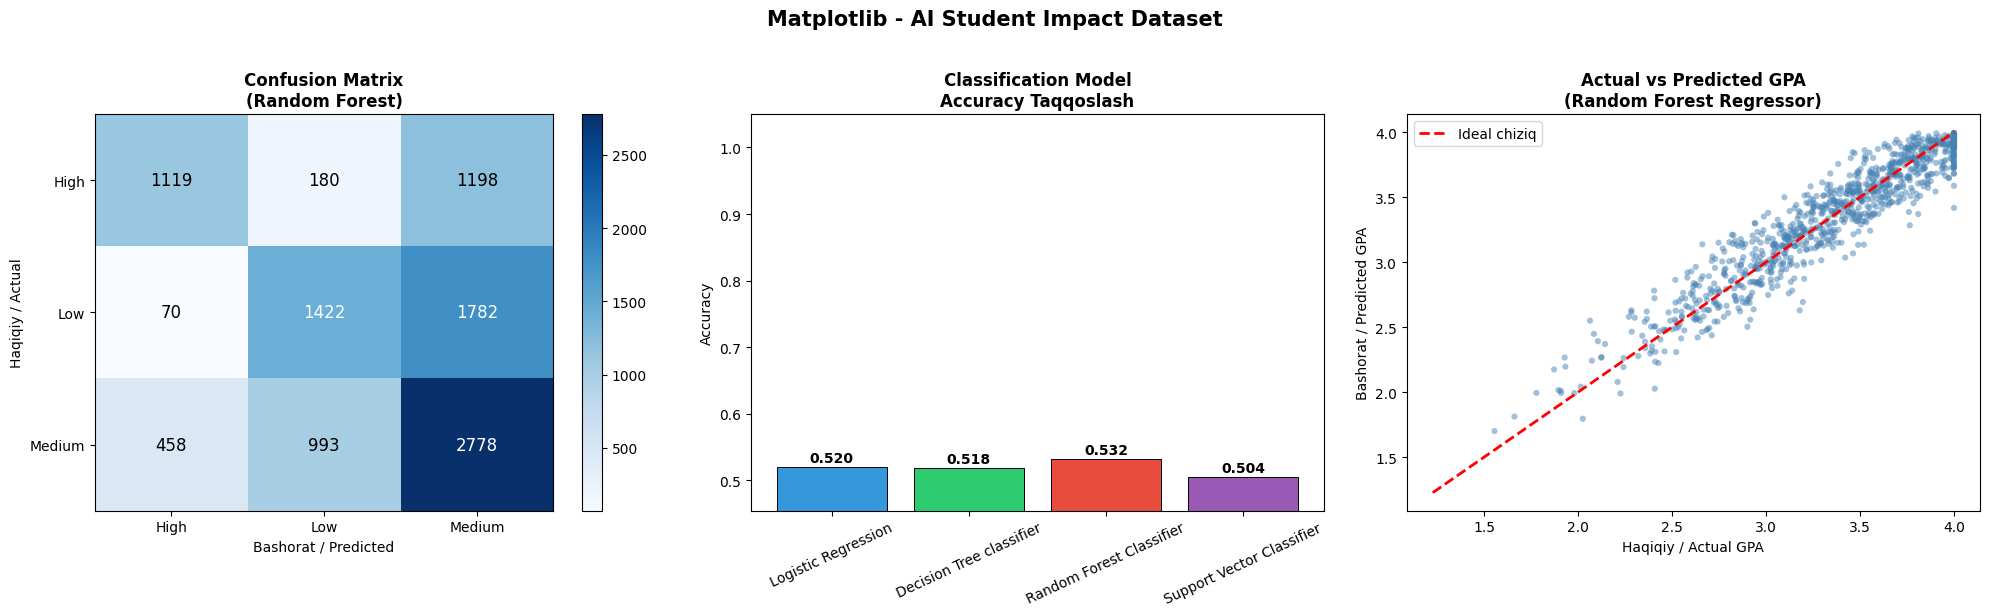

 Matplotlib grafiklari saqlandi!


In [ ]:
# ============================================================
# Matplotlib - 3 xil grafik
# ============================================================

 # Matplotlib - Python dagi eng asosiy grafik kutubxona
  # Matplotlib - core plotting library in Python
 # QACHON: Oddiy, tez, maxsus sozlash kerak bo'lganda
  # WHEN: Simple, fast, custom configurations needed

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    # plt.subplots(...) -> grafik oynasi yaratadi, ichida subplotlar hosil qiladi
    # (1, 3, ...) -> 1 qator, 3 ustun degani (Misol: [ Grafik1 ] [ Grafik2 ] [ Grafik3 ])
    # plt.subplots(2,2) -> [1] [2]
    #                   -> [3] [4]
    # fig -> katta oyna         
    # axes -> subplotlar listi (Misol: axes[0],  axes[1], axes[2]) (Har biri alohida grafik)
fig.suptitle('Matplotlib - AI Student Impact Dataset', fontsize=15, fontweight='bold', y=1.02)

 # --- Grafik 1: Confusion Matrix (Random Forest Classifier) ---
  # Model qaysi klasslarni to'gri, qaysilarini noto'g'ri bashorat qilganini ko'rsatadi
   # Shows which classes the model predicted correctly and incorrectly
classes = sorted(y_test_clf.unique())
cm_rf = confusion_matrix(y_test_clf, y_pred_rf_clf, labels = classes)
im = axes[0].imshow(cm_rf, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(len(classes)))
axes[0].set_yticks(range(len(classes)))
axes[0].set_xticklabels(classes)
axes[0].set_yticklabels(classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        axes[0].text(j,i, cm_rf[i, j], ha='center', va='center', fontsize=12,
                    color='white' if cm_rf[i, j] > cm_rf.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Confusion Matrix\n(Random Forest)', fontweight='bold')
axes[0].set_xlabel('Bashorat / Predicted')
axes[0].set_ylabel('Haqiqiy / Actual')

 # --- Grafik 2: Classification Model Accuracy Bar ---
  # Barcha classification modellarning accuracy ni taqqoslash
   # Comparing accuracy of all classification models
clf_names = [r['model'].replace(' Classifier ', '').replace(' Regresssion', '') for r in clf_results]
clf_accs = [r['accuracy'] for r in clf_results]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = axes[1].bar(clf_names, clf_accs, color=colors, edgecolor='black', linewidth=0.7)
axes[1].set_ylim([min(clf_accs) - 0.05, 1.05])
axes[1].set_title('Classification Model\nAccuracy Taqqoslash', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x',rotation=25)
for bar, acc in zip(bars, clf_accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

 # --- Grafik 2: Actual vs Predicted (Random Forest Regressor) ---
  # Haqiqiy GPA va bashorat qilingan GPA ni taqqoslash
   # Comparing actual GPA vs predicted GPA
  # Ideal = barcha nuqtalar qizil chiziqda bo'ladi
   # Ideal = all points on the red line
sample_idx = np.random.choice(len(y_test_reg), size=1000, replace=False)
axes[2].scatter(y_test_reg.iloc[sample_idx], y_pred_rf_reg[sample_idx],
                alpha=0.5, color='steelblue', edgecolors='none', s=20)
mn, mx = y_test_reg.min(), y_test_reg.max()
axes[2].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Ideal chiziq')
axes[2].set_title('Actual vs Predicted GPA\n(Random Forest Regressor)',fontweight='bold')
axes[2].set_xlabel('Haqiqiy / Actual GPA')
axes[2].set_ylabel('Bashorat / Predicted GPA')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join('data_analysis', '02_matplotlib_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Matplotlib grafiklari saqlandi!")

### Seaborn

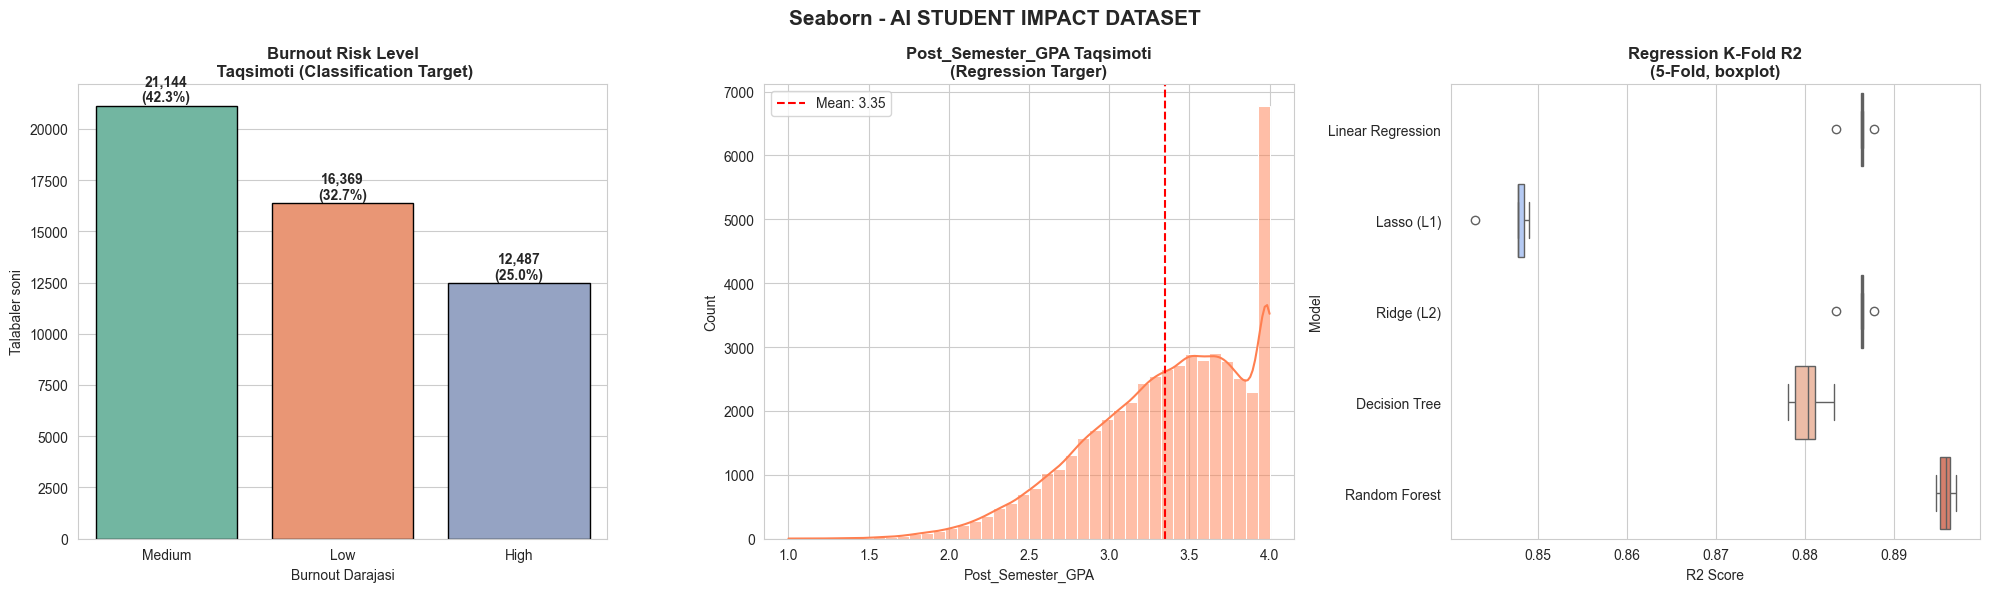

 Seaborn grafiklari saqlandi!


In [ ]:
# ============================================================
# SEABORN - 3 xil grafik
# ========================================================

    # Seaborn - Matplotlib ustiga qurilgan statistik vizualizatsiya
     # Seaborn - statistical visualization built on Matplotlib
    # Qachon: Statistik tahlilm chiroyli default stil, taqsimot va boxplot
     # WHEN: Statistical analysis, beaitiful default style, distribution and boxplots

sns.set_style('whitegrid')
sns.set_palette('husl')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Seaborn - AI STUDENT IMPACT DATASET', fontsize=15, fontweight='bold')

 # --- Seaborn Grafik 1: Burnout Level taqsimoti (Targer) ---
  # Target klasslarning taqsimoti - imbalanced holat bormi?
   # Distribution of target classes - is it imbalanced?
burnout_counts = df['Burnout_Risk_Level'].value_counts()
sns.barplot(x=burnout_counts.index, y=burnout_counts.values, ax=axes[0],
            palette='Set2', edgecolor='black')
for i, (idx, val) in enumerate(burnout_counts.items()):
    axes[0].text(i, val + 200, f'{val:,}\n({val/len(df)*100:.1f}%)',
        ha='center', fontweight='bold')
axes[0].set_title('Burnout Risk Level\n Taqsimoti (Classification Target)', fontweight='bold')
axes[0].set_xlabel('Burnout Darajasi')
axes[0].set_ylabel('Talabaler soni')

 # --- Seaborn Grafik 2: Post GPA taqsimoti (Regression Target) ---
  # Regression target taqsimoti - normal yoki skewed?
   # Regression target distribution - normal or skewed?
sns.histplot(data=df, x='Post_Semester_GPA', kde=True, ax=axes[1],
            color='coral', bins=40)
axes[1].axvline(df['Post_Semester_GPA'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['Post_Semester_GPA'].mean():.2f}")
axes[1].set_title('Post_Semester_GPA Taqsimoti\n(Regression Targer)', fontweight='bold')
axes[1].legend()

 # --- Seaborn Grafik 3: Regression Model K-Fold R2 ---
  # K-Fold natijalarini violin + strip plot orqali ko'rsatish
   # Show K-Fold results via violin + strip plot
kf_reg_data = []
for name, vals in reg_kf_results.items():
    for score in vals['scores']:
        kf_reg_data.append({'Model': name, 'R2': score})
kd_reg_df = pd.DataFrame(kf_reg_data)

sns.boxplot(data=kd_reg_df, x='R2', y='Model', ax=axes[2], palette='coolwarm')
axes[2].set_title('Regression K-Fold R2\n(5-Fold, boxplot)', fontweight='bold')
axes[2].set_xlabel('R2 Score')

plt.tight_layout()
plt.savefig(os.path.join('data_analysis', '03_seaborn_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Seaborn grafiklari saqlandi!")

### Plotly Express

In [ ]:
# ============================================================
# PLOTLY EXPRESS - 3 xil interaktiv grafik
# ============================================================

    # Plotly - interaktiv grafiklar. Sichqoncha bilan hover, zoom, pan qilsa bo'ladi
     # Plotly - interactive charts, Can hover, zoom, pan with mouse
    # Qachon: Presentation, dashboard, ko'p o'lchovli data vizualizatsiyasi
     # WHEN: Presentations, dashboards, multi-dimensional data visualization

# --- Plotly Grafik 1: Feature Importance (Random Forest Classifier) ---
 # Qaysi feature Burnout_Risk_Level ga ko'proq ta'sir qiladi?
  # Which feature influences Burnout_Risk_Level more?
 # Feature importance = model qaysi ustunlarga ko'proq ta'sir qiladi?
  # Feature importance = which columns the model paid most attention to

feat_imp_clf = pd.DataFrame({
    'Feature': X_clf.columns,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=True)

fig1 = px.bar(
    feat_imp_clf, x='Importance', y='Feature', orientation='h',
    title='Feature Importance - Random Forest (Burnout Prediction)',
    color='Importance', color_continuous_scale='Viridis',
    labels={'Importance': 'Muhimlik darajasi / Importance', 'Feature': 'Xususiyat / Featur'}
)
fig1.show()
fig1.write_html(os.path.join('data_analysis', 'plotly_feature_importance.html'))

 # --- Plotly Grafik 2: Scatter - Weekly AI Hours vs Post GPA ---
  # AI ishlatish soati va GPA orasidagi bog'liqlikni interaktiv ko'rish
   # Interactive view of relationship between AI usage hours and GPA
sample_df = df.sample(2000, random_state=42)
fig2 = px.scatter(
    sample_df, x='Weekly_GenAI_Hours', y='Post_Semester_GPA',
    color='Burnout_Risk_Level', size='Skill_Retention_Score',
    hover_data=['Major_Category', 'Year_of_Study', 'Prompt_Engineering_Skill'],
    title='AI Ishlatish Soati vs Post Semester GPA<br>(Burnout darajasi bo\'yicha ranglangan)',
    labels={
        'Weekly_GenAI_Hours': 'Haftada AI soati / Weekly AI Hours',
        'Post_Semester_GPA': 'Post Semester GPA'
    },
    color_discrete_map={'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}
)
fig2.show()
fig2.write_html(os.path.join('data_analysis', 'plotly_scatter.html'))

 # --- Plotly Grafik 3: Classification Model Comparison ---
  # Barcha metriklar bo'yicha modellarni interaktiv taqqoslash
   # Interactive comparison of models across all metrics
clf_metrics_df = pd.DataFrame(clf_results)
clf_melt = clf_metrics_df.melt(
    id_vars='model',
    value_vars=['accuracy', 'precision', 'recall', 'f1'],
    var_name='Metric', value_name='Score'
)
fig3 = px.bar(
    clf_melt, x='model', y='Score', color='Metric', barmode='group',
    title='Classification Modellari - Barcha Metriklar Taqqoslash',
    labels={'model': 'Model', 'Score': 'Ball / Score'},
    range_y=[0,1.1]
)
fig3.update_layout(xaxis_tickangle=-20)
fig3.show()
fig3.write_html(os.path.join('data_analysis', 'plotly_clf_comparison.html'))

print(" Plotly grafiklari saqlandi (HTML ko'rinishida)!")

 Plotly grafiklari saqlandi (HTML ko'rinishida)!


---
## Bashorat Natijalarini va Engineered Datani Saqlash

In [ ]:
# ============================================================
# Predictions va Engineered Data Saqlash
# ============================================================

    # Classification bashoratlari / Classification predictions
clf_pred_df = pd.DataFrame({
    'actual_burnout': y_test_clf.values,
    'logistic_regression': y_pred_lr,
    'decision_tree': y_pred_dt_clf,
    'random_fores': y_pred_rf_clf,
    'svc': y_pred_svc
})
clf_pred_path = os.path.join('data', 'predictions', 'classifications.csv')
clf_pred_df.to_csv(clf_pred_path, index=False)
print(f" Classification predictions: {clf_pred_path}")
print(clf_pred_df.head())

    # Regression bashoratlari / Regression predictions
reg_pred_df = pd.DataFrame({
    'actual_gpa': y_test_reg.values,
    'linear_regression': y_pred_lin,
    'lasso_l1': y_pred_lasso,
    'ridge_l2': y_pred_ridge,
    'decision_tree': y_pred_dt_reg,
    'random_forest': y_pred_rf_reg,
    'svr': y_pred_svr
})
reg_pred_path  = os.path.join('data', 'predictions', 'regression_predictions.csv')
reg_pred_df.to_csv(reg_pred_path, index=False)
print(f" \n Regression predictions: {reg_pred_path}")
print(reg_pred_df.head())

    # Engineered data (preprocessed + target)
X_clf_final = X_clf.copy()
X_clf_final['target_burnout'] = y_clf.values
X_clf_final.to_csv(os.path.join('data', 'engineered', 'clf_engineered.csv'), index=False)
print(f"\n Engineered dataset (CLF) saqlandi")

 Classification predictions: data\predictions\classifications.csv
  actual_burnout logistic_regression decision_tree random_fores     svc
0         Medium              Medium          High       Medium  Medium
1         Medium              Medium           Low       Medium     Low
2            Low              Medium        Medium       Medium  Medium
3         Medium                 Low        Medium       Medium  Medium
4           High                High          High         High    High
 
 Regression predictions: data\predictions\regression_predictions.csv
   actual_gpa  linear_regression  lasso_l1  ridge_l2  decision_tree  \
0       2.582           2.373344  3.348073  2.374212       2.390030   
1       3.452           3.108896  3.348073  3.109190       3.173223   
2       3.035           3.165051  3.348073  3.165186       3.211261   
3       2.754           2.646685  3.348073  2.647300       2.720762   
4       3.084           3.040646  3.348073  3.040956       3.173223   

   r

---
## Yakuniy Papka Tuzilmasi

In [ ]:
# ============================================================
# Yakuniy Papka Tuzilmasi
# ============================================================

def print_tree(path, prefix=''):
    if not os.path.exists(path):
        return
    items = sorted(os.listdir(path))
    for i, item in enumerate(items):
        is_last = i == len(items) - 1
        connector = '└──' if is_last else '├── '
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            print(f"{prefix}{connector}📁 {item}/")
            print_tree(item_path, prefix + ('    ' if is_last else '│   '))
        else:
            size = os.path.getsize(item_path)
            size_str = f"{size/1024:.1f}KB" if size > 1024 else f"{size}B"
            print(f"{prefix}{connector}📄 {item} ({size_str})")

print(" Loyiha Papka Tuzilmasi / Project Folder Structure")
print("="*60)
for folder in ['data', 'data_analysis', 'model']:
    if os.path.exists(folder):
        print(f"\n {folder}/")
        print_tree(folder, '   ')

print("\n" + "="*60)
print(" Loyiha Muvafaqqiyatli Yakunlandi!")
print(" Project Succussfully completed!")
print("="*60)

 Loyiha Papka Tuzilmasi / Project Folder Structure

 data/
   ├── 📁 engineered/
   │   └──📄 clf_engineered.csv (8950.4KB)
   ├── 📁 predictions/
   │   ├── 📄 classifications.csv (290.0KB)
   │   └──📄 regression_predictions.csv (1152.9KB)
   ├── 📁 preprocessed/
   │   ├── 📄 X_clf_preprocessed.csv (8681.0KB)
   │   └──📄 X_reg_preprocessed.csv (8502.1KB)
   └──📁 raw_datasets/
       └──📄 ai_student_impact.csv (5803.2KB)

 data_analysis/
   ├── 📄 01_correlation_matrix.png (143.3KB)
   ├── 📄 02_matplotlib_plots.png (233.9KB)
   ├── 📄 03_seaborn_plots.png (127.7KB)
   ├── 📄 plotly_clf_comparison.html (4742.6KB)
   ├── 📄 plotly_feature_importance.html (4742.1KB)
   └──📄 plotly_scatter.html (4875.6KB)

 Loyiha Muvafaqqiyatli Yakunlandi!
 Project Succussfully completed!


---
## 🎓 XULOSA / SUMMARY

| # | Bosqich | Nima qilindi? | Qaysi kutubxona? |
|---|---------|--------------|------------------|
| 0 | OS Papkalar | Loyiha tuzilmasi yaratildi | `os` |
| 1 | Import | Barcha kutubxonalar | hammalari |
| 2 | Dataset | 50,000 qator, 16 ustun yuklandi | `pandas` |
| 3 | EDA | Klib + df.corr() + heatmap | `klib`, `seaborn` |
| 4 | Duplicates | Tekshirildi va tozalandi | `pandas` |
| 5 | Missing Values | 5 usul tushuntirildi (mean/median/mode/fixed/drop) | `sklearn.impute` |
| 6 | Encoding | 5 usul (label/onehot/ordinal/binary/target) | `sklearn` |
| 7 | Scaling | 5 usul (standard/minmax/robust/maxabs/normalizer) | `sklearn` |
| 8 | X/y Ajratish | CLF: Burnout, REG: Post_GPA | `pandas` |
| 9 | Preprocessing | Funksiya: mean+mode+label+minmax | `sklearn` |
| 10 | Train-Test Split | 80/20, stratify | `sklearn` |
| 11 | Model Train | 4 CLF + 6 REG (Lasso L1, Ridge L2) | `sklearn` |
| 12 | Evaluation | CLF: acc/prec/rec/f1/logloss/cm; REG: r2/mae/mse/rmse | `sklearn.metrics` |
| 13 | K-Fold CV | K=5, numpy mean/std | `sklearn`, `numpy` |
| 14 | Tabulate | Jadval taqqoslash, eng yaxshi model | `tabulate` |
| 15 | Joblib | 10 ta model saqlandi | `joblib` |
| 16 | Vizualizatsiya | Matplotlib + Seaborn + Plotly (har biridan 3 grafik) | vizualizatsiya kutubxonalari |
| 17 | Predictions | CSV ga bashoratlar saqlandi | `pandas` |

---
### 🏆 Lasso vs Ridge qachon?
- **Lasso (L1)** → Ko'p feature, ba'zilarini o'chirib tashlash kerak → **Feature Selection**
- **Ridge (L2)** → Featurelar o'zaro kuchli bog'liq (multicollinearity) → **Barqarorlashtirish**

### 🏆 Scaling qachon kerak emas?
- **Decision Tree** (Classifier va Regressor) → Faqat `x <= threshold` taqqoslaydi, arifmetik yo'q
- **Random Forest** → Tree-based, masofani hisoblamaydi

### 🏆 X/y ajratish qachon?
- **Preprocessing DAN OLDIN** → Scaler/Imputer faqat X ga qo'llanadi, y ga EMAS!